In [1]:
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, find_peaks_cwt
import matplotlib.pyplot as plt
import pickle
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
from statsmodels.stats.power import TTestPower

with open('/home/metamobility5/Changseob/proj-online_adaptation_GPE/method-torque_profile_generation/torque_splines.pkl', 'rb') as f:
    torque_splines = pickle.load(f)

def upsampling(data, target_length):
    """
    Upsample a 1D numpy array to the desired target length using linear interpolation.
    """
    original_length = len(data)
    original_indices = np.linspace(0, original_length - 1, original_length)
    new_indices = np.linspace(0, original_length - 1, target_length)

    return np.interp(new_indices, original_indices, data)

def upsampling_2d(data, target_length):
    """
    Upsample a 2D numpy array to the desired target length using linear interpolation.
    data: numpy array of shape (n_features, n_samples)
    target_length: desired length of each segment after upsampling
    """
    upsampled_data = np.zeros((data.shape[0], target_length))
    for i in range(data.shape[0]):
        upsampled_data[i, :] = upsampling(data[i, :], target_length)

    return upsampled_data

def segmenting(data, peak_indices, target_length=50, number_of_cycles=None):
    """
    Segment the data based on gait cycle indices and return all segments and their average.
    data: numpy array of shape (n_samples, n_features)
    peak_indices: numpy array of shape (n_peak) with start and end indices of each gait cycle
    target_length: desired length of each segment after upsampling
    """
    segments = np.zeros((len(peak_indices) - 1, data.shape[1], target_length))

    for n, (start, end) in enumerate(zip(peak_indices[:-1], peak_indices[1:])):
        for i in range(data.shape[1]):
            segment = data[start:end+1, i]
            segment_upsampled = upsampling(segment, target_length)
            segments[n, i, :] = segment_upsampled
    
    if number_of_cycles is not None:
        segments = segments[:number_of_cycles, :, :]

    return segments # (number_of_cycles, n_features, target_length)

def gait_cycle_generator(peak_indices, num_cycles=None):
    gc_angle_list = []
    gc_polar_x_list = []
    gc_polar_y_list = []

    if num_cycles is None:
        num_cycles = len(peak_indices) - 1
    for i in range(num_cycles):
        start = peak_indices[i]
        end = peak_indices[i + 1]

        for j in range(start, end):
            gc_polar_angle = (j - start) / (end - start) * 2 * np.pi
            gc_angle_list.append(gc_polar_angle)
            gc_polar_x_list.append(np.cos(gc_polar_angle))
            gc_polar_y_list.append(np.sin(gc_polar_angle))

    return np.column_stack((gc_polar_x_list, gc_polar_y_list))

def polar_to_percentage(polar_coords):
    angle = np.arctan2(polar_coords[:, 1], polar_coords[:, 0])
    percentage = (angle + 2*np.pi) % (2 * np.pi) / (2 * np.pi) * 100  # Normalize to (0, 100]
    return percentage

def load_jetson_input_mtr_data(file_path, trigger_indices=None):
    df = pd.read_csv(file_path, delimiter=',')
    motor_data = df.values
    # 0: timestamp, 1: pos_L, 2: pos_R, 3: vel_L, 4: vel_R, 5: gpio
    if trigger_indices is not None:
        motor_data = motor_data[trigger_indices[0]:trigger_indices[1], :]
    return motor_data

def load_jetson_output_data(file_path, trigger_indices=None):
    df = pd.read_csv(file_path, delimiter=',')
    output_data = df.values
    # 0: timestamp, 1: gait_phase_L, 2: gait_phase_R, 3: mtr_cmd_L, 4: mtr_cmd_R, 5: gpio_output
    if trigger_indices is not None:
        output_data = output_data[trigger_indices[0]:trigger_indices[1], :]
    return output_data

def load_PC_buffer_data(file_path, trigger_indices=None):
    df = pd.read_csv(file_path, delimiter=',')
    return df

def detect_heel_strike(GRF_data, threshold, min_interval, max_interval, side, xlim=None):
    # Create binary signal based on threshold
    bi_grf = np.where(GRF_data < threshold, 0, 1)
    diff_grf = np.diff(bi_grf)

    # Find indices where the signal goes from 0 to 1
    heelstrike_index = np.where(diff_grf == 1)[0] + 1
    if heelstrike_index.size == 0:
        return np.array([], dtype=int)

    # Filter out the heel strike indices that are too close or too far apart
    valid_heelstrikes = heelstrike_index[np.insert(np.diff(heelstrike_index) >= min_interval, 0, True)]
    # valid_heelstrikes = valid_heelstrikes[np.insert(np.diff(valid_heelstrikes) <= max_interval, 0, True)]

    # valid_heelstrikes = heelstrike_index[np.insert(np.diff(heelstrike_index) >= min_interval, 0, True)]

    # # Find anomalies in heel strike indices
    # hs_anomaly_idx = np.where(np.diff(valid_heelstrikes)> max_interval)
    # leave_out_gc = hs_anomaly_idx[0].tolist()
    # # Find indices of specific values in numpy array
    # print(f"Leave-out-gait-cycles ({side}): {len(leave_out_gc)}")
    # for gc in leave_out_gc:
    #     closest_index = min(range(len(valid_heelstrikes)), key=lambda i: abs(valid_heelstrikes[i] - valid_heelstrikes[gc]))
    #     # print(f"Closest value: {valid_heelstrikes[closest_index]/100} at index: {closest_index}")

    return valid_heelstrikes

def plot_hs_detection(mtr_data, imu_data, peak_indices, side='R', xlim=None):
    time = mtr_data[:, 0]
    if side == 'R':
        signal = mtr_data[:, 6] # right fsr
    elif side == 'L':
        signal = mtr_data[:, 5] # left fsr

    plt.figure(figsize=(12, 2))
    plt.plot(time, signal, lw=1)
    # pick only peak indices
    plt.plot(time[peak_indices], signal[peak_indices], 'rx', markersize=8, label='peaks')
    print(f"Detected heel strikes at times: {time[peak_indices]}")
    # for idx, peak in enumerate(peak_indices):
    #     plt.text(time[peak], signal[peak], str(signal[peak]), fontsize=8, ha='center', va='bottom')
    prev_div = 0
    # for div in course_dur:
    #     plt.axvline(prev_div + div, color='r', linestyle='--')
    #     prev_div += div
    plt.xlabel('Time (s)')
    plt.ylabel('FSR value')
    plt.title(f'Detected heel strikes {side} side')
    plt.legend()
    plt.show()

def get_prediction_accuracy(predictions, ground_truth, torque_cmd, torque_label, hs_indices, task_segments, leave_out_gc, course_name, course_dur):
    error_list, torque_error_list = [], []
    
    gc_rmse_list, torque_rmse_list = [], []
    for gc in range(len(hs_indices)-1):
        if gc in leave_out_gc:
            error_list.extend([np.nan] * (hs_indices[gc+1] - hs_indices[gc]))
            continue
        start_idx = hs_indices[gc]
        end_idx = hs_indices[gc+1]

        gc_error_list = []
        for i in range(start_idx, end_idx):
            error = ground_truth[i-hs_indices[0]] - predictions[i-hs_indices[0]]
            torque_error = torque_label[i-hs_indices[0]] - torque_cmd[i-hs_indices[0]]
            # torque_error = 1 - torque_cmd[i-hs_indices[0]] / torque_label[i-hs_indices[0]] if torque_label[i-hs_indices[0]] != 0 else 0
            if error < -50:
                error_list.append(error + 100)
                gc_error_list.append(error + 100)
            elif error > 50:
                error_list.append(error - 100)
                gc_error_list.append(error - 100)
            else:
                error_list.append(error)
                gc_error_list.append(error)
            torque_error_list.append(torque_error)
        gc_rmse_list.append(np.sqrt(np.nanmean((np.array(gc_error_list)) ** 2)))
        torque_rmse_list.append(np.sqrt(np.nanmean((np.array(torque_error_list)) ** 2)))
    
    rmse = np.sqrt(np.nanmean((np.array(error_list)) ** 2))

    course_rmse_list, course_rmse_torque_list = [], []
    if course_name <= 3:
        if task_segments is not None:
            for seg in task_segments:
                # seg: (start_time, end_time, incline, speed)
                start_t, end_t = seg[0], seg[1]

                # Find closest HS indices corresponding to time
                # Note: Assuming 100Hz sampling rate roughly matches index/100
                closest_start = hs_indices[np.argmin(np.abs(hs_indices - start_t*100))]
                closest_end = hs_indices[np.argmin(np.abs(hs_indices - end_t*100))]
                
                # Map absolute HS indices to relative error_list indices (offset by first HS)
                idx_start = max(0, closest_start - hs_indices[0])
                idx_end = max(0, closest_end - hs_indices[0])
                
                # Clamp to valid error_list range
                idx_start = min(idx_start, len(error_list))
                idx_end = min(idx_end, len(error_list))

                if idx_start < idx_end:
                    course_error = error_list[idx_start:idx_end]
                    course_torque_error = torque_error_list[idx_start:idx_end]
                    course_rmse_list.append(np.sqrt(np.nanmean((np.array(course_error)) ** 2)))
                    course_rmse_torque_list.append(np.sqrt(np.nanmean((np.array(course_torque_error)) ** 2)))
                else:
                    pass  # No valid data for this segment
    else:    
        # Clamp to valid error_list range
        idx_start = hs_indices[0]
        idx_end = hs_indices[-1]

        if idx_start < idx_end:
            course_error = error_list[idx_start:idx_end]
            course_torque_error = torque_error_list[idx_start:idx_end]
            course_rmse_list.append(np.sqrt(np.nanmean((np.array(course_error)) ** 2)))
            course_rmse_torque_list.append(np.sqrt(np.nanmean((np.array(course_torque_error)) ** 2)))

    # course_rmse_torque_list = course_rmse_torque_list / np.abs(torque_label).max() * 100 # normalize to percentage

    return rmse, course_rmse_list, course_rmse_torque_list, gc_rmse_list, torque_rmse_list, error_list

def plot_gait_phase_prediction(output_data, gait_phase_label, rmse, error_list, course_rmse, hs_indices, segments, start_sec, side, leave_out_gc, xlim=None):
    # Plot prediction vs. ground truth
    plt.figure(figsize=(12, 2))
    if side == 'L':
        plt.plot(output_data[hs_indices[0]:hs_indices[-1], 0] - start_sec, output_data[hs_indices[0]:hs_indices[-1], 1], color='dodgerblue', label='predicted gait phase', lw=1)
    elif side == 'R':
        plt.plot(output_data[hs_indices[0]:hs_indices[-1], 0] - start_sec, output_data[hs_indices[0]:hs_indices[-1], 2], color='dodgerblue', label='predicted gait phase', lw=1)
    plt.plot(output_data[hs_indices[0]:hs_indices[-1], 0] - start_sec, gait_phase_label, lw=1, linestyle='--', color='k', label='gait phase label')
    
    if segments is not None:
        for i, seg in enumerate(segments):
            plt.axvline(seg[1], color='r', linestyle='--')

    for gc in leave_out_gc:
        if gc < len(hs_indices) - 1:
            plt.axvspan(output_data[hs_indices[gc], 0], output_data[hs_indices[gc+1], 0], color='gray', alpha=0.3)
    plt.xlabel('time (s)')
    plt.ylabel('Gait phase (%)')
    plt.title(f'Gait Phase {side} - RMSE: {rmse:.2f} %')
    if xlim is not None: plt.xlim(xlim)
    plt.legend()
    plt.show()

    # # Plot error (gait phase label - predicted)
    # plt.figure(figsize=(40, 5))
    # plt.plot(output_data[hs_indices[0]:hs_indices[-1], 0] - start_sec, np.array(error_list), lw=1, linestyle='--', color='g', label='error (gait phase label - predicted)')
    
    # if segments is not None:
    #     for i, seg in enumerate(segments):
    #         # seg: (start_time, end_time, incline, speed)
    #         plt.axvline(seg[1], color='r', linestyle='--')
            
    #         mid_time = (seg[0] + seg[1]) / 2
    #         course_name_str = f"{seg[3]}m/s"
            
    #         plt.text(mid_time, 15, course_name_str, rotation=0, color='r', ha='center', fontsize=20)
    #         if i < len(course_rmse) and not np.isnan(course_rmse[i]):
    #             plt.text(mid_time, 10, f'{course_rmse[i]:.2f}', rotation=0, color='r', ha='center', fontsize=20)

    # for gc in leave_out_gc:
    #     if gc < len(hs_indices) - 1:
    #         plt.axvspan(output_data[hs_indices[gc], 0], output_data[hs_indices[gc+1], 0], color='gray', alpha=0.3)
    # plt.xlabel('time (s)')
    # plt.ylabel('Error (%)')
    # plt.title(f'Gait Phase {side} Error - RMSE: {rmse:.2f} %')
    # plt.axhline(y=0, color='black', linestyle='--')
    # plt.ylim(-20, 20)
    # plt.legend()
    # plt.show()
# ...existing code...

incline_keys = {"RD_5deg": -5, "LG": 0, "RA_5deg": 5}
speed_keys = {"0p4mps": 0.4, "0p6mps": 0.6, "0p8mps": 0.8, "1p0mps": 1.0, "1p2mps": 1.2, "1p4mps": 1.4}

def plot_course_rmses(segments, subjects, adapted_rmse_R, adapted_rmse_L, pc_buffer_rmse_R, pc_buffer_rmse_L, adapted_rmse_torque_R, adapted_rmse_torque_L, pc_buffer_rmse_torque_R, pc_buffer_rmse_torque_L):

    course_name = []
    for seg in segments:
        spd = 'slow' if seg[3] == 0.3 else 'mid'
        inc = 'LG' if seg[2] == 0 else ('RA' if seg[2] == 10 else 'RD')
        course_name.append(f"{seg[4]}. {inc} - {spd}")

    adapted_rmse = {}
    pc_buffer_rmse = {}
    adapted_rmse_torque = {}
    pc_buffer_rmse_torque = {}
    for subject in subjects:
        adapted_rmse[subject] = np.mean(
            [
                np.asarray(adapted_rmse_R[subject], dtype=float),
                np.asarray(adapted_rmse_L[subject], dtype=float),
            ],
            axis=0
        )
        pc_buffer_rmse[subject] = np.mean(
            [
                np.asarray(pc_buffer_rmse_R[subject], dtype=float),
                np.asarray(pc_buffer_rmse_L[subject], dtype=float),
            ],
            axis=0
        )

    adapted_rmse_avg = np.mean(list(adapted_rmse.values()), axis=0)[:6]
    adapted_rmse_std = np.std(list(adapted_rmse.values()), axis=0)[:6]
    pc_buffer_rmse_avg = np.mean(list(pc_buffer_rmse.values()), axis=0)[:6]
    pc_buffer_rmse_std = np.std(list(pc_buffer_rmse.values()), axis=0)[:6]
    
    fig, ax = plt.subplots(figsize=(4, 2))
    x_pos = np.arange(len(course_name))[:6]

    print(f"Adapted RMSE avg across all tasks: {np.mean(adapted_rmse_avg):.2f} %")
    print(f"PC Buffer RMSE avg across all tasks: {np.mean(pc_buffer_rmse_avg):.2f} %")

    ax.plot(x_pos, adapted_rmse_avg, c = 'k', marker='o',label='Adapted', linewidth=1, linestyle='--')
    ax.fill_between(x_pos, adapted_rmse_avg - adapted_rmse_std, adapted_rmse_avg + adapted_rmse_std, color='k', alpha=0.2)
    ax.plot(x_pos, pc_buffer_rmse_avg, c = 'dodgerblue', marker='o', label='PC Buffer', linewidth=1, linestyle='--')
    ax.fill_between(x_pos, pc_buffer_rmse_avg - pc_buffer_rmse_std, pc_buffer_rmse_avg + pc_buffer_rmse_std, color='dodgerblue', alpha=0.2)

    ax.set_xlabel('Locomotion course (incline - speed)', fontsize=12)
    ax.set_ylabel('Gait phase RMSE (%)', fontsize=12)
    # ax.set_title(f'Course-wise RMSE ({side})')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_pos+1, rotation=0)
    # ax.legend(loc='upper left', fontsize=8)
    ax.set_xlim(0, len(course_name[:6])-1)
    ax.set_ylim(0, 22.5)

    plt.tight_layout()
    plt.rcParams['pdf.fonttype'] = 42
    plt.savefig('Course_RMSE_plot.pdf', dpi=300)
    plt.show()


    # # Mean ± std summary across 4 conditions
    # condition_data = {
    #     # "Static": static_rmse,
    #     "Adapted": adapted_rmse,
    #     # "Task Buffer": task_buffer_rmse,
    #     "PC Buffer": pc_buffer_rmse,
    # }

    # torque_condition_data = {
    #     # "Static": static_rmse_torque,
    #     "Adapted": adapted_rmse_torque,
    #     # "Task Buffer": task_buffer_rmse_torque,
    #     "PC Buffer": pc_buffer_rmse_torque,
    # }

    # means, stds, labels = [], [], []; means_torque, stds_torque = [], []
    # for name, values in condition_data.items():
    #     if values is not None and len(values) > 0:
    #         arr = np.asarray(values, dtype=float)
    #         mean_val = np.mean(arr[5-1:]) #np.nanmean(arr)
    #         mean_val_torque = np.mean(np.asarray(torque_condition_data[name], dtype=float)[5-1:]) #np.nanmean(np.asarray(torque_condition_data[name], dtype=float))
    #         std_val = 0 #np.nanstd(arr)
    #         std_val_torque = 0 #np.nanstd(np.asarray(torque_condition_data[name], dtype=float))
    #         print(f"{name} ({side}) -> mean: {mean_val:.2f}, std: {std_val:.2f}, mean torque: {mean_val_torque:.2f}, std torque: {std_val_torque:.2f}")
    #     else:
    #         mean_val = np.nan; mean_val_torque = np.nan
    #         std_val = np.nan; std_val_torque = np.nan
    #         print(f"{name} ({side}) -> mean: nan, std: nan, mean torque: nan, std torque: nan")

    #     labels.append(name)
    #     means.append(mean_val); means_torque.append(mean_val_torque)
    #     stds.append(std_val); stds_torque.append(std_val_torque)

    # # Assuming labels, means, stds, means_torque, and stds_torque are already defined
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
    # x_cond = np.arange(len(labels))
    # colors = ['k', 'm', 'r', 'b']

    # # Subplot 1: Gait phase RMSE
    # ax1.bar(
    #     x_cond,
    #     np.nan_to_num(means, nan=0.0),
    #     yerr=np.nan_to_num(stds, nan=0.0),
    #     capsize=5,
    #     color=colors,
    #     alpha=0.8
    # )
    # ax1.set_xticks(x_cond)
    # ax1.set_xticklabels(labels, rotation=00)
    # ax1.set_ylabel('Gait phase RMSE (%)')
    # ax1.set_xlabel('Condition')
    # ax1.set_ylim(0, 10)
    # ax1.set_title('Gait Phase Accuracy')

    # # Subplot 2: Torque RMSE
    # ax2.bar(
    #     x_cond,
    #     np.nan_to_num(means_torque, nan=0.0),
    #     yerr=np.nan_to_num(stds_torque, nan=0.0),
    #     capsize=5,
    #     color=colors,
    #     alpha=0.8
    # )
    # ax2.set_xticks(x_cond)
    # ax2.set_xticklabels(labels, rotation=00)
    # ax2.set_ylabel('Torque RMSE ($N \cdot m$)')
    # ax2.set_xlabel('Condition')
    # ax2.set_title('Torque Tracking Accuracy')

    # plt.tight_layout()
    # plt.show()

def plot_course_rmses_2(subjects, adapted_rmse_R, adapted_rmse_L, pc_buffer_rmse_R, pc_buffer_rmse_L, data='gc'):
    adapted_rmse = {}
    pc_buffer_rmse = {}
    for subject in subjects:
        adapted_rmse[subject] = np.mean([
            np.asarray(adapted_rmse_R[subject], dtype=float),
            np.asarray(adapted_rmse_L[subject], dtype=float)
        ], axis=0)
        pc_buffer_rmse[subject] = np.mean([
            np.asarray(pc_buffer_rmse_R[subject], dtype=float),
            np.asarray(pc_buffer_rmse_L[subject], dtype=float)
        ], axis=0)

    def summarize_subject_group(rmse_dict, indices):
        per_subject = []
        for subject in subjects:
            arr = np.asarray(rmse_dict[subject], dtype=float)
            per_subject.append(np.nanmean(arr[indices]) if arr.size > max(indices) else np.nan)
        return np.asarray(per_subject, dtype=float)

    cond_names = ['LG_Diff', 'RA_Same', 'RA_Diff', 'RD_Same', 'RD_Diff']
    indices = [[7, 13], [8, 15], [9, 14], [10, 17], [11, 16]]

    print("Subjects where adapted RMSE < pc_buffer RMSE (averaged across all courses and sides):")
    for condition in cond_names:
        print(f"\nCondition: {condition}")
        for subject in subjects:
            idx = indices[cond_names.index(condition)]
            a = np.nanmean(np.asarray(adapted_rmse[subject][idx], dtype=float))
            p = np.nanmean(np.asarray(pc_buffer_rmse[subject][idx], dtype=float))
            if a < p:
                print(f"{subject}: adapted={a:.1f}, pc_buffer={p:.1f}, difference={a-p:.3f}")

    data_list = []
    condition_arrays = {}
    for name, idx in zip(cond_names, indices):
        a_vals = summarize_subject_group(adapted_rmse, idx)
        p_vals = summarize_subject_group(pc_buffer_rmse, idx)
        condition_arrays[name] = {'Adapted': a_vals, 'PC_buffer': p_vals}

        for val in a_vals:
            data_list.append({'RMSE': val, 'Method': 'Adapted', 'Condition': name})
        for val in p_vals:
            data_list.append({'RMSE': val, 'Method': 'PC_buffer', 'Condition': name})

    df = pd.DataFrame(data_list).dropna()
    model = ols('RMSE ~ C(Method) + C(Condition) + C(Method):C(Condition)', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\n--- TWO-WAY ANOVA RESULTS ---")
    print(anova_table)

    posthoc_p_values = {}
    num_tests = len(cond_names)
    power_calc = TTestPower()
    print("\n--- POWER ANALYSIS (Target: 80% Power, Bonferroni Alpha = 0.01) ---")

    for name in cond_names:
        a = condition_arrays[name]['Adapted']
        p = condition_arrays[name]['PC_buffer']
        _, p_raw = stats.ttest_rel(a, p, nan_policy='omit')
        p_corrected = 1.0 if np.isnan(p_raw) else min(1.0, p_raw * num_tests)
        posthoc_p_values[name] = p_corrected

        differences = a - p
        mean_diff = np.nanmean(differences)
        std_diff = np.nanstd(differences, ddof=1)
        if not np.isfinite(std_diff) or std_diff == 0:
            continue

        cohen_dz = mean_diff / std_diff
        try:
            required_n = power_calc.solve_power(
                effect_size=cohen_dz,
                alpha=0.01,
                power=0.80,
                alternative='two-sided'
            )
            print(f"Condition: {name: <15} | Cohen's dz: {cohen_dz: >5.2f} | Required N: {np.ceil(required_n):.0f}")
        except ValueError:
            print(f"Condition: {name: <15} | Effect size too small to reliably calculate N.")

    fig, axes = plt.subplots(1, 5, figsize=(12, 3), sharey=False)
    rng = np.random.default_rng(42)
    subject_cmap = plt.get_cmap('tab10', len(subjects))
    subject_colors = {subject: subject_cmap(i) for i, subject in enumerate(subjects)}

    def draw_bar_with_subject_scatter(ax, title, cond_key, show_ylabel=False):
        a_vals = condition_arrays[cond_key]['Adapted']
        p_vals = condition_arrays[cond_key]['PC_buffer']

        a_mean, a_std = np.nanmean(a_vals), np.nanstd(a_vals)
        p_mean, p_std = np.nanmean(p_vals), np.nanstd(p_vals)

        x = np.array([0, 1])
        ax.bar(x, [a_mean, p_mean], yerr=[a_std, p_std], color=['k', 'dodgerblue'], alpha=0.6, capsize=5, width=0.6)

        jitter = rng.uniform(-0.2, 0.2, len(subjects))
        for i, subject in enumerate(subjects):
            color = subject_colors[subject]
            if np.isfinite(a_vals[i]) and np.isfinite(p_vals[i]):
                ax.plot([x[0] + jitter[i], x[1] + jitter[i]], [a_vals[i], p_vals[i]], color=color, alpha=0.35, linewidth=1, zorder=2)
            if np.isfinite(a_vals[i]):
                ax.scatter(x[0] + jitter[i], a_vals[i], s=35, facecolors=[color], edgecolors='none', linewidths=0.5, zorder=3, alpha=0.7)
            if np.isfinite(p_vals[i]):
                ax.scatter(x[1] + jitter[i], p_vals[i], s=35, facecolors=[color], edgecolors='none', linewidths=0.5, zorder=3, alpha=0.7)

        p_corr = posthoc_p_values[cond_key]
        if p_corr < 0.001:
            sig_text = '***'
        elif p_corr < 0.01:
            sig_text = '**'
        elif p_corr < 0.05:
            sig_text = '*'
        # else:
        #     sig_text = f'(p={p_corr:.2f})'

        valid_vals = np.concatenate([a_vals[np.isfinite(a_vals)], p_vals[np.isfinite(p_vals)]])
        max_y = (np.max(valid_vals) if valid_vals.size else 0) + 0.0
        if p_corr < 0.05:
            ax.plot([0, 0, 1, 1], [max_y, max_y*1.05, max_y*1.05, max_y], lw=1, color='black')
            ax.text(0.5, max_y*1.05, sig_text, ha='center', va='bottom', color='black', fontsize=12)

        ax.set_title(title, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(['Adapted\nw/o replay', 'Manifold-aware\nreplay'])
        if show_ylabel:
            ax.set_ylabel('Gait phase RMSE (%)') if data == 'gc' else ax.set_ylabel('Torque RMSE (N-m)')
        # ax.set_ylim(0, max_y * 1.2)
        # if data is not 'gc':
        #     for j in [0, 3, 4]:
        #         axes[j].set_ylim(0, 3)
        #     for j in [1, 2]:
        #         axes[j].set_ylim(0, 7.5)
        from matplotlib.ticker import MaxNLocator
        for j in range(5):
            axes[j].yaxis.set_major_locator(MaxNLocator(nbins=3))   # about 4 major ticks
        # ax.set_ylim(0, 13 if data == 'gc' else 3)

        return a_mean, a_std, p_mean, p_std
        

    titles = ['LG, Different speed', 'LG to RA, Same speed', 'LG to RA, Different speed', 'LG to RD, Same speed', 'LG to RD, Different speed']
    a_means, a_stds, p_means, p_stds = [], [], [], []
    for i, (name, title) in enumerate(zip(cond_names, titles)):
        a_mean, a_std, p_mean, p_std = draw_bar_with_subject_scatter(axes[i], title, name, show_ylabel=(i == 0))
        a_means.append(a_mean); a_stds.append(a_std); p_means.append(p_mean); p_stds.append(p_std)
    
    a_means_arr = np.array(a_means);    a_stds_arr = np.array(a_stds)
    p_means_arr = np.array(p_means);    p_stds_arr = np.array(p_stds)
    print(f'Adapted means: {[f"{mean:.2f} ± {std:.2f}" for (mean, std) in zip(a_means_arr, a_stds_arr)]}')
    print(f'PC Buffer means: {[f"{mean:.2f} ± {std:.2f}" for (mean, std) in zip(p_means_arr, p_stds_arr)]}')
    pct_diff = (a_means_arr - p_means_arr) / p_means_arr * 100
    print(f'Mean percentage difference (Adapted - PC Buffer): {[f"{x:.2f}" for x in pct_diff]}')
    print(f'Mean Adapted: {np.mean(a_means):.2f} Mean PC Buffer: {np.mean(p_means):.2f}')
    print(f'Overall mean percentage difference: {((np.mean(a_means) - np.mean(p_means)) / np.mean(p_means) * 100):.2f}%')

    from matplotlib.lines import Line2D
    subject_handles = [
        Line2D([0], [0], marker='o', color='w', label=subject, markerfacecolor=subject_colors[subject], markersize=6, markeredgecolor='none', markeredgewidth=0, alpha=0.7)
        for subject in subjects
    ]
    fig.legend(handles=subject_handles, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=len(subjects), frameon=False, title='Subjects')

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.rcParams['pdf.fonttype'] = 42
    plt.savefig('Torque_RMSE_plot.pdf', dpi=300)
    plt.show()
    
def process_representative_rmse(subjects, rmse_R, rmse_L, hs_indices, data = 'gc'):
    condition_map = {
    "LG - Different Speed": (7, 13),
    "LG to RA - Same Speed": (8, 15),
    "LG to RA - Different Speed": (9, 14),
    "LG to RD - Same Speed": (10, 17),
    "LG to RD - Different Speed": (11, 16),
    }

    # Store three representative trajectories per condition.
    # Each case is selected from Adapted scores, then matched to the same
    # subject/side/course in PC Buffer for fair comparison.
    gc_rmse_cases_per_condition = {}
    hs_idx_cases_per_condition = {}
    all_y_vals = []

    case_order = ['H', 'M', 'L']

    fig, axes = plt.subplots(1, 15, figsize=(12, 3), sharex=True, sharey=True)

    for cond_col, (condition, (idx1, idx2)) in enumerate(condition_map.items()):
        print(f"\nCondition: {condition}")
        all_candidates = []
        for subject in subjects:
            for side_sel, rmse_side in [('R', rmse_R), ('L', rmse_L)]:
                for course_idx in [idx1, idx2]:
                    curve = rmse_side['adapted'][subject][course_idx]
                    score = np.nanmean(np.asarray(curve, dtype=float))
                    if np.isfinite(score):
                        all_candidates.append({
                            'subject': subject,
                            'side': side_sel,
                            'course_idx': course_idx,
                            'score': score,
                            'adapted_curve': list(curve),
                            'adapted_hs': list(hs_indices['adapted'][subject][course_idx] / 100),
                        })

        if len(all_candidates) == 0:
            print("No finite candidates found for this condition.")
            continue

        all_candidates = sorted(all_candidates, key=lambda x: x['score'])
        selected_idx = {
            'L': 0,
            'M': len(all_candidates) // 2,
            'H': len(all_candidates) - 1,
        }

        gc_rmse_cases_per_condition[condition] = {}
        hs_idx_cases_per_condition[condition] = {}

        for case_col, case_name in enumerate(case_order):
            ax_idx = cond_col * 3 + case_col
            ax = axes[ax_idx]
            case = all_candidates[selected_idx[case_name]]

            subject_sel = case['subject']
            side_sel = case['side']
            course_idx_sel = case['course_idx']

            adapted_curve = case['adapted_curve']
            adapted_hs = case['adapted_hs']
            adapted_min_len = min(len(adapted_curve), len(adapted_hs))

            if side_sel == "R":
                pc_curve = list(rmse_R['pc_buffer'][subject_sel][course_idx_sel])
            else:
                pc_curve = list(rmse_L['pc_buffer'][subject_sel][course_idx_sel])
            pc_hs = list(hs_indices['pc_buffer'][subject_sel][course_idx_sel] / 100)
            pc_min_len = min(len(pc_curve), len(pc_hs))

            gc_rmse_cases_per_condition[condition][case_name] = {
                'adapted': adapted_curve[:adapted_min_len],
                'pc_buffer': pc_curve[:pc_min_len],
            }
            all_y_vals.extend([v for v in gc_rmse_cases_per_condition[condition][case_name]['adapted'] if np.isfinite(v)])
            all_y_vals.extend([v for v in gc_rmse_cases_per_condition[condition][case_name]['pc_buffer'] if np.isfinite(v)])
            hs_idx_cases_per_condition[condition][case_name] = {
                'adapted': adapted_hs[:adapted_min_len],
                'pc_buffer': pc_hs[:pc_min_len],
            }

            print(
                f"{case_name:>7}",
                subject_sel,
                side_sel,
                course_idx_sel,
                f"score={case['score']:.3f}",
                len(hs_idx_cases_per_condition[condition][case_name]['adapted']),
                len(hs_idx_cases_per_condition[condition][case_name]['pc_buffer']),
            )

            ax.plot(
                hs_idx_cases_per_condition[condition][case_name]['adapted'],
                gc_rmse_cases_per_condition[condition][case_name]['adapted'],
                color='k',
                linestyle='-',
                alpha=0.85,
                marker='o',
                markersize=2.5,
                linewidth=1,
                label='Adapted',
            )
            ax.plot(
                hs_idx_cases_per_condition[condition][case_name]['pc_buffer'],
                gc_rmse_cases_per_condition[condition][case_name]['pc_buffer'],
                color='dodgerblue',
                linestyle='-',
                alpha=0.85,
                marker='o',
                markersize=2.5,
                linewidth=1,
                label='PC Buffer',
            )

            ax.set_title(condition if case_col == 1 else '')
            ax.set_xlabel(case_name.capitalize())

        # ax.set_yticks([0, 10, 20, 30])
    if len(all_y_vals) > 0:
        y_min = float(np.min(all_y_vals))
        y_max = float(np.max(all_y_vals))
        if np.isclose(y_min, y_max):
            y_pad = max(0.5, abs(y_min) * 0.1)
        else:
            y_pad = (y_max - y_min) * 0.05
        y_lower = y_min - y_pad
        y_upper = y_max + y_pad
        y_ticks = np.linspace(y_lower, y_upper, 4)
        for ax in axes:
            ax.set_ylim(y_lower, y_upper)
            # ax.set_yticks(y_ticks)
    if data == 'gc':
        axes[0].set_ylabel('Gait Phase RMSE (%)')
        axes[0].set_xlim(-1, 8)
        axes[0].set_ylim(0, 35)
        axes[0].set_xticks([])
        axes[0].set_yticks([0, 10, 20, 30])
    else:
        axes[0].set_ylabel('Torque RMSE (N-m)')
        axes[0].set_xlim(-1, 8)
        axes[0].set_ylim(0, 6)
        axes[0].set_xticks([])
        axes[0].set_yticks([0, 2, 4, 6])

    for j in range(0, 15):
        axes[j].spines['right'].set_visible(False)
        axes[j].spines['top'].set_visible(False)
    handles, labels = axes[0].get_legend_handles_labels()
    # fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)

    # Keep each 3-panel condition cluster tight, and add larger gaps between clusters.
    left, right = 0.04, 0.995
    bottom, top = 0.23, 0.86
    small_gap = 0.004
    large_gap = 0.06
    total_w = right - left
    total_gap = 10 * small_gap + 4 * large_gap
    ax_w = (total_w - total_gap) / 15
    ax_h = top - bottom

    for i, ax in enumerate(axes):
        large_before = i // 3
        small_before = i - large_before
        x = left + i * ax_w + small_before * small_gap + large_before * large_gap
        ax.set_position([x, bottom, ax_w, ax_h])
    
    if data == 'gc':    
        plt.rcParams['pdf.fonttype'] = 42
        plt.savefig('Representative_gc.pdf', dpi=300)
        plt.show()
    else:
        plt.rcParams['pdf.fonttype'] = 42
        plt.savefig('Representative_torque.pdf', dpi=300)
        plt.show()


def plot_gc_rmses(segments, adapted_rmse_R, adapted_rmse_L, pc_buffer_rmse_R, pc_buffer_rmse_L, side='Overall'):
    def _build_course_curves(r_courses, l_courses):
        course_curves = []

        for r_curve, l_curve in zip(r_courses, l_courses):
            r_curve = np.asarray(r_curve, dtype=float)
            l_curve = np.asarray(l_curve, dtype=float)

            if side == 'R':
                course_curve = r_curve
            elif side == 'L':
                course_curve = l_curve
            else:
                n = min(len(r_curve), len(l_curve))
                course_curve = (
                    np.nanmean(np.vstack([r_curve[:n], l_curve[:n]]), axis=0)
                    if n > 0 else np.array([], dtype=float)
                )

            course_curves.append(course_curve)

        unfolded = np.concatenate([c for c in course_curves if len(c) > 0]) if any(len(c) > 0 for c in course_curves) else np.array([], dtype=float)
        return course_curves, unfolded

    adapted_courses, adapted_unfolded = _build_course_curves(adapted_rmse_R, adapted_rmse_L)
    pc_courses, pc_unfolded = _build_course_curves(pc_buffer_rmse_R, pc_buffer_rmse_L)

    n_courses = min(len(segments), len(adapted_courses), len(pc_courses))
    display_lengths = [
        int(round(np.mean([len(adapted_courses[i]), len(pc_courses[i])])))
        for i in range(n_courses)
    ]
    boundaries = np.concatenate([[0], np.cumsum(display_lengths)])
    centers = (boundaries[:-1] + boundaries[1:]) / 2
    course_labels = [
        f"{seg[4]}" if len(seg) > 4 else str(i + 1)
        for i, seg in enumerate(segments[:n_courses])
    ]

    plt.figure(figsize=(16, 4), dpi=200)
    plt.plot(np.arange(len(adapted_unfolded)), adapted_unfolded, color='k', lw=1, label='Adapted')
    plt.plot(np.arange(len(pc_unfolded)), pc_unfolded, color='dodgerblue', lw=1, label='PC Buffer')

    for boundary in boundaries:
        plt.axvline(boundary, color='gray', linestyle=':', linewidth=1, alpha=0.7)

    plt.xticks(centers, course_labels)
    plt.xlabel('Sequential gait cycles across 18 courses')
    plt.ylabel('Gait phase RMSE (%)')
    plt.title(f'Unfolded gait-cycle RMSE ({subject}, {side})')
    plt.ylim(0, 30)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_torque(torque_cmd, torque_label, side='L'):
    plt.figure(figsize=(12, 2))
    if side == 'L':
        plt.plot(torque_cmd, lw=1, label='Torque Command', color='blue')
    elif side == 'R':
        plt.plot(torque_cmd, lw=1, label='Torque Command', color='red')
    plt.plot(torque_label, lw=1, label='Torque Label', color='black', linestyle='--')
    plt.xlabel('Time (s)')
    plt.ylabel('Torque (N-m)')
    plt.legend()
    plt.show()

def plot_positive_power(angular_velocity, torque_cmd):
    power = -angular_velocity * torque_cmd
    positive_power = np.where(power > 0, power, 0)

    work = np.sum(power) / 100  # Assuming 100 Hz sampling rate, convert to Joules 
    positive_work = np.sum(positive_power) / 100  # Assuming 100 Hz sampling rate, convert to Joules
    print(f"Positive work done: {positive_work:.2f} J")

    plt.figure(figsize=(30, 4))
    plt.plot(power, lw=1, label='Power', color='green', linestyle='--')
    plt.plot(positive_power, lw=1, label='Positive Power', color='orange')
    plt.xlabel('Time (s)')
    plt.ylabel('Power (W)')
    plt.legend()
    plt.show()

    return work, positive_work

def plot_imu_saggital(imu_data):
    plt.figure(figsize=(30, 4))
    plt.plot(imu_data[:, 0], imu_data[:, 3], lw=1, label='L_Acc_Z', color='blue')
    plt.plot(imu_data[:, 0], imu_data[:, 9], lw=1, label='R_Acc_Z', color='red')
    plt.xlabel('Time (s)')
    plt.ylabel('IMU acc (m/s²)')
    plt.legend()
    plt.show()

def plot_jerk(imu_data):
    jerk_L = np.diff(imu_data[:, 3]) * 100  # L_Acc_Z
    jerk_R = np.diff(imu_data[:, 9]) * 100  # R_Acc_Z

    plt.figure(figsize=(30, 4))
    plt.plot(imu_data[1:, 0], jerk_L, lw=1, label='L_Acc_Jerk', color='blue')
    plt.plot(imu_data[1:, 0], jerk_R, lw=1, label='R_Acc_Jerk', color='red')
    plt.xlim(40, 60)
    plt.ylim(-1000, 1000)
    plt.xlabel('Time (s)')
    plt.ylabel('IMU acc jerk (m/s³)')
    plt.legend()
    plt.show()

In [2]:
weight_kg = {'SK_Jimin': 80, 'SK_Maria' : 57, 'SK_Marvin': 56, 'SK_David': 60, 'SK_Ilseung': 85, 'SK_Changseob': 73, 'SK_Oscar': 72, 'SK_Amy': 54, 'SK_Rajiv': 61, 'SK_Atri': 82, 'SK_Itak': 72, 'SK_Crystal': 59, 'SK_Cole': 82, 'SK_Jinwoo': 88}

In [3]:
# SK Rajiv's Force plate threshold is 0.15! (There is a trial that was not zeroed)

In [4]:
segments_condition = [  # (start_time, end_time, incline, speed)
    (0, 10, 0, 0.3),  # first segment is warm-up (should not be included in analysis)
    (10, 40, 0, 0.3, '1'),
    (40, 70, 0, 0.7, '2'),
    (70, 100, 10, 0.3, '3'),
    (100, 130, 10, 0.7, '4'),
    (130, 160, -10, 0.3, '5'),
    (160, 190, -10, 0.7, '6'),
    (190, 490, 0, 0.3, '7-1'),
    (490, 520, 0, 0.7, '8-1'),
    (520, 550, 10, 0.3, '8-2'),
    (550, 580, 10, 0.7, '8-3'),
    (580, 610, -10, 0.3, '8-4'),
    (610, 640, -10, 0.7, '8-5'),
    (640, 940, 0, 0.7, '7-2'),
    (940, 970, 0, 0.3, '8-6'),
    (970, 1000, 10, 0.3, '8-7'),
    (1000, 1030, 10, 0.7, '8-8'),
    (1030, 1060, -10, 0.3, '8-9'),
    (1060, 1090, -10, 0.7, '8-10'),
    # (910, 940, 0, 0.3),
    # (940, 970, 10, 0.3),
]

# Arrays for plotting speed as a function of time (exclude warm-up)
segments_analysis = segments_condition[1:]
speed_time = np.array([segments_analysis[0][0]] + [seg[1] for seg in segments_analysis], dtype=float)
speed_value = np.array([seg[3] for seg in segments_analysis] + [segments_analysis[-1][3]], dtype=float)

segments_course = [ # (start_time, end_time, incline, speed)
    (0, 30, 0, 0.3),
    # (30, 60, 0, 0.7),
    # (30, 60, 0, 0.5),
    # (60, 90, 0, 0.2),
]

incline_values = {'RD': -10, 'RD_slow': -10, 'RD_fast': -10, 'LG': 0, 'LG_slow': 0, 'LG_fast': 0, 'RA': 10, 'RA_slow': 10, 'RA_fast': 10}

In [5]:
course_num = ['1_1', '2_1', '3_1', '4_1', '5_1', '6_1']


In [6]:
scale_factor = 0.3; torque_limit = 12.5
# course_num = ['1_1', '2_1', '3_1', '4_1', '5_1', '6_1', '7_1', '8_1', '8_2', '8_3', '8_4', '8_5', '7_2', '8_6', '8_7', '8_8', '8_9', '8_10']
course_num = ['1_1', '2_1', '3_1', '4_1', '5_1', '6_1']
course_num_eval = ['8_1', '8_2', '8_3', '8_4', '8_5', '8_6', '8_7', '8_8', '8_9', '8_10']
incline = ['LG_slow', 'LG_fast', 'RA_slow', 'RA_fast', 'RD_slow', 'RD_fast', 'LG_slow', 'LG_fast', 'RA_slow', 'RA_fast', 'RD_slow', 'RD_fast', 'LG_fast', 'LG_slow', 'RA_slow', 'RA_fast', 'RD_slow', 'RD_fast']
eval_len = 10
course_len = [eval_len] * len(course_num); data_idx = [[0, eval_len*100] for _ in course_num]
course_len[:6] = [30]*6; #course_len[6] = 300; course_len[12] = 300; 
data_idx[:6] = [[0, 30*100]]*6; #data_idx[6] = [0, 300*100]; data_idx[12] = [0, 300*100]
start_sec = 10

start_idx_per_course_L, start_idx_per_course_R = [], []

subjects = ['SK_Rajiv', 'SK_Jimin', 'SK_Maria', 'SK_Marvin', 'SK_Itak', 'SK_Crystal', 'SK_Cole', 'SK_Jinwoo', 'SK_David']
# subjects = ['SK_Maria', 'SK_Itak']
conditions = ['adapted', 'pc_buffer']

# list to store RMSE values for each subject and condition
gc_rmse_L, gc_rmse_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
torque_rmse_L, torque_rmse_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
hs_indices = {condition: {subject: [] for subject in subjects} for condition in conditions}
course_rmse_L, course_rmse_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
course_rmse_torque_L, course_rmse_torque_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
course_work_L, course_work_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
course_pos_work_L, course_pos_work_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}

input_reduced_L, input_reduced_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
grid_key_L, grid_key_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
grid_task_label_L, grid_task_label_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
grid_course_label_L, grid_course_label_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
inc_idx_L, inc_idx_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
spd_idx_L, spd_idx_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
start_idx_L, start_idx_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}
update_latency_L, update_latency_R = {condition: {subject: [] for subject in subjects} for condition in conditions}, {condition: {subject: [] for subject in subjects} for condition in conditions}

input_reduced_PC_L, input_reduced_PC_R = {condition: {subject: {inc: [] for inc in incline} for subject in subjects} for condition in conditions}, {condition: {subject: {inc: [] for inc in incline} for subject in subjects} for condition in conditions}

for subject in subjects:
    subject_kg = weight_kg[subject]
    for condition in conditions:
        for course, inc in zip(course_num, incline):
            course_idx = int(course.split('_')[0]) - 1
            print(f'Processing Course {course} - Incline: {inc}')
            root_folder = f'/home/metamobility5/Changseob/proj-online_adaptation_GPE/analysis-main_exp/{subject}'
            mtr_data = load_jetson_input_mtr_data(f'{root_folder}/{subject}-{condition}-{course}_{inc}-input_motor.csv', trigger_indices=data_idx[course_idx])
            imu_data = load_jetson_input_mtr_data(f'{root_folder}/{subject}-{condition}-{course}_{inc}-input_imu.csv', trigger_indices=data_idx[course_idx])
            output_data = load_jetson_output_data(f'{root_folder}/{subject}-{condition}-{course}_{inc}-output_torque.csv', trigger_indices=data_idx[course_idx])
            PC_L_data = load_PC_buffer_data(f'{root_folder}/{subject}-{condition}-{course}_{inc}-pc_L.csv')
            PC_R_data = load_PC_buffer_data(f'{root_folder}/{subject}-{condition}-{course}_{inc}-pc_R.csv')

            # Stack start indices for each course, adjusting by course length to get absolute indices in the full dataset
            start_idx_per_course_L = PC_L_data['update_start_idx_L'].tolist(); start_idx_per_course_R = PC_R_data['update_start_idx_R'].tolist()
            start_idx_per_course_L = [idx for idx in start_idx_per_course_L if start_sec*100 < idx < (course_len[course_idx]+start_sec)*100]; start_idx_per_course_R = [idx for idx in start_idx_per_course_R if start_sec*100 < idx < (course_len[course_idx]+start_sec)*100]
            start_idx_L[condition][subject].extend([idx + (sum(course_len[:course_idx])-start_sec)*100 for idx in start_idx_per_course_L]); start_idx_R[condition][subject].extend([idx + (sum(course_len[:course_idx])-start_sec)*100 for idx in start_idx_per_course_R])

            # Stack incline, speed, and PC values corresponding to each start index
            inc_L_list = output_data[[idx - start_sec*100 for idx in start_idx_per_course_L], -3]; inc_R_list = output_data[[idx - start_sec*100 for idx in start_idx_per_course_R], -3]
            spd_L_list = output_data[[idx - start_sec*100 for idx in start_idx_per_course_L], -2]; spd_R_list = output_data[[idx - start_sec*100 for idx in start_idx_per_course_R], -2]
            spd_idx_L[condition][subject].extend(spd_L_list); spd_idx_R[condition][subject].extend(spd_R_list); inc_idx_L[condition][subject].extend(inc_L_list); inc_idx_R[condition][subject].extend(inc_R_list)
            len_L = len(spd_L_list); len_R = len(spd_R_list)

            # Stack input_reduced values corresponding to each start index
            indices_ = [i for i, x in enumerate(PC_L_data['update_start_idx_L']) if x in set(start_idx_per_course_L)]
            input_reduced_L[condition][subject].extend([PC_L_data['input_reduced_L'][i] for i in indices_]); grid_key_L[condition][subject].extend([PC_L_data['grid_key_L'][i] for i in indices_])
            input_reduced_PC_L[condition][subject][inc].extend([PC_L_data['input_reduced_L'][i] for i in indices_]); update_latency_L[condition][subject].extend([PC_L_data['update_latency_L'][i] for i in indices_])
            grid_task_label_L[condition][subject].extend([inc] * len(indices_)); grid_course_label_L[condition][subject].extend([course] * len(indices_))
            indices_ = [i for i, x in enumerate(PC_R_data['update_start_idx_R']) if x in set(start_idx_per_course_R)]
            input_reduced_R[condition][subject].extend([PC_R_data['input_reduced_R'][i] for i in indices_]); grid_key_R[condition][subject].extend([PC_R_data['grid_key_R'][i] for i in indices_])
            grid_task_label_R[condition][subject].extend([inc] * len(indices_)); grid_course_label_R[condition][subject].extend([course] * len(indices_))            
            input_reduced_PC_R[condition][subject][inc].extend([PC_R_data['input_reduced_R'][i] for i in indices_]); update_latency_R[condition][subject].extend([PC_R_data['update_latency_R'][i] for i in indices_])

            # Detect heel strikes
            grf_threshold = 0.15 if subject == 'SK_Rajiv' else 0.10
            print(f"Using GRF threshold of {grf_threshold} for heel strike detection.")
            hs_indices_L = detect_heel_strike(mtr_data[:, 5], threshold=grf_threshold, min_interval=50, max_interval=210, side='L')[:-2]
            hs_indices_R = detect_heel_strike(mtr_data[:, 6], threshold=grf_threshold, min_interval=50, max_interval=210, side='R')[:-2]
            print(f'Number of detected heel strikes - Left: {len(hs_indices_L)}, Right: {len(hs_indices_R)}')
            # print(hs_indices_L, hs_indices_R)

            # Use from first to last heel strikes for analysis to ensure full gait cycles
            gait_phase_label_L = polar_to_percentage(gait_cycle_generator(hs_indices_L))
            gait_phase_label_R = polar_to_percentage(gait_cycle_generator(hs_indices_R))
            predictions_R = output_data[hs_indices_R[0]:hs_indices_R[-1], 2]
            predictions_L = output_data[hs_indices_L[0]:hs_indices_L[-1], 1]

            torque_cmd_R = output_data[hs_indices_R[0]:hs_indices_R[-1], 4]
            torque_cmd_L = output_data[hs_indices_L[0]:hs_indices_L[-1], 3]

            # Get gt and predicted torque values using the spline functions for each incline and speed
            speeds_L = output_data[hs_indices_L[0]:hs_indices_L[-1], -2]; speeds_R = output_data[hs_indices_R[0]:hs_indices_R[-1], -2]
            torque_label_L = np.array([torque_splines[incline_values[inc]][s][int(gp)] 
                        for s, gp in zip(speeds_L, gait_phase_label_L)]) * subject_kg * scale_factor
            torque_label_L = np.clip(torque_label_L, -torque_limit, torque_limit)  # Clip to torque limits
            torque_label_R = np.array([torque_splines[incline_values[inc]][s][int(gp)] 
                        for s, gp in zip(speeds_R, gait_phase_label_R)]) * subject_kg * scale_factor
            torque_label_R = np.clip(torque_label_R, -torque_limit, torque_limit)  # Clip to torque limits
            torque_pred_L = np.array([torque_splines[incline_values[inc]][s][int(p)] 
                        for s, p in zip(speeds_L, predictions_L)]) * subject_kg * scale_factor
            torque_pred_R = np.array([torque_splines[incline_values[inc]][s][int(p)] 
                        for s, p in zip(speeds_R, predictions_R)]) * subject_kg * scale_factor

            rmse_L, _course_rmse_L, _course_rmse_torque_L, _gc_rmse_L, _torque_rmse_L, error_list_L = get_prediction_accuracy(predictions_L, gait_phase_label_L, torque_cmd_L, torque_label_L, hs_indices_L, segments_course, leave_out_gc=[], course_name=course_idx + 1, course_dur=None)
            rmse_R, _course_rmse_R, _course_rmse_torque_R, _gc_rmse_R, _torque_rmse_R, error_list_R = get_prediction_accuracy(predictions_R, gait_phase_label_R, torque_cmd_R, torque_label_R, hs_indices_R, segments_course, leave_out_gc=[], course_name=course_idx + 1, course_dur=None)
            
            course_rmse_L[condition][subject].extend(_course_rmse_L);   course_rmse_R[condition][subject].extend(_course_rmse_R);   course_rmse_torque_L[condition][subject].extend(_course_rmse_torque_L);   course_rmse_torque_R[condition][subject].extend(_course_rmse_torque_R)
            gc_rmse_L[condition][subject].append(_gc_rmse_L); gc_rmse_R[condition][subject].append(_gc_rmse_R); hs_indices[condition][subject].append(hs_indices_L)
            torque_rmse_L[condition][subject].append(_torque_rmse_L); torque_rmse_R[condition][subject].append(_torque_rmse_R)

            # if course in course_num_eval:
            #     plot_hs_detection(mtr_data, imu_data, hs_indices_L, side='L', xlim=None)
            #     plot_hs_detection(mtr_data, imu_data, hs_indices_R, side='R', xlim=None)
                # plot_gait_phase_prediction(output_data, gait_phase_label_L, rmse_L, error_list_L, _course_rmse_L, hs_indices_L, segments_course, start_sec, side='L', leave_out_gc=[], xlim=None)
                # plot_gait_phase_prediction(output_data, gait_phase_label_R, rmse_R, error_list_R, _course_rmse_R, hs_indices_R, segments_course, start_sec, side='R', leave_out_gc=[], xlim=None)
                # plot_torque(torque_cmd_L, torque_label_L, side='L')
                # plot_torque(torque_cmd_R, torque_label_R, side='R')

            # work, positive_work = plot_positive_power(imu_data[hs_indices_L[0]:hs_indices_L[-1], 5], torque_cmd_L)
            # course_work_L.append(work); course_pos_work_L.append(positive_work)
            # work, positive_work = plot_positive_power(imu_data[hs_indices_R[0]:hs_indices_R[-1], 11], torque_cmd_R)
            # course_work_R.append(work); course_pos_work_R.append(positive_work)

            # plot_imu_saggital(imu_data)
            # plot_jerk(imu_data)

Processing Course 1_1 - Incline: LG_slow
Using GRF threshold of 0.15 for heel strike detection.
Number of detected heel strikes - Left: 19, Right: 20
Processing Course 2_1 - Incline: LG_fast
Using GRF threshold of 0.15 for heel strike detection.
Number of detected heel strikes - Left: 25, Right: 26
Processing Course 3_1 - Incline: RA_slow
Using GRF threshold of 0.15 for heel strike detection.
Number of detected heel strikes - Left: 19, Right: 19
Processing Course 4_1 - Incline: RA_fast
Using GRF threshold of 0.15 for heel strike detection.
Number of detected heel strikes - Left: 25, Right: 26
Processing Course 5_1 - Incline: RD_slow
Using GRF threshold of 0.15 for heel strike detection.
Number of detected heel strikes - Left: 20, Right: 19
Processing Course 6_1 - Incline: RD_fast
Using GRF threshold of 0.15 for heel strike detection.
Number of detected heel strikes - Left: 25, Right: 26
Processing Course 1_1 - Incline: LG_slow
Using GRF threshold of 0.15 for heel strike detection.
Numb

/tmp/ipykernel_663394/2989432797.py:38: RuntimeWarning: Mean of empty slice
  grand_mean = np.nanmean(all_bin_means, axis=0)
/home/metamobility5/miniconda3/envs/cs_tcn/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


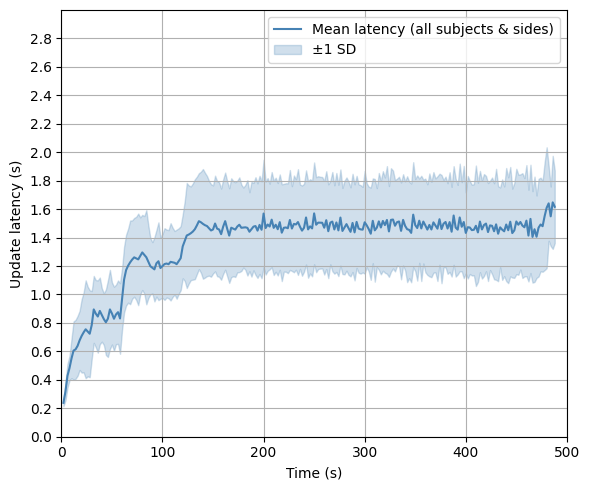

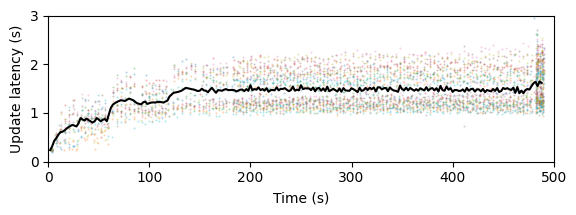

In [128]:
time_grid = np.arange(0, 490, 2)
bin_w = 2
bin_edges = np.append(time_grid, time_grid[-1] + bin_w)
n_bins = len(time_grid)

def interp_nan(arr):
    s = pd.Series(arr)
    return s.interpolate(method='linear', limit_area='inside').values

# Collect per-bin mean latency for every subject × side combination
# Shape: (n_subjects * 2_sides, n_bins)
all_bin_means = []
subject_cmap = plt.get_cmap('tab10', len(subjects))
subject_colors = {subject: subject_cmap(i) for i, subject in enumerate(subjects)}
raw_by_subject = {subject: {'t': [], 'lat': []} for subject in subjects}

for subject in subjects:
    for side_key, lat_dict, idx_dict in [
        ('L', update_latency_L, start_idx_L),
        ('R', update_latency_R, start_idx_R),
    ]:
        start_t = np.asarray(idx_dict['pc_buffer'][subject], dtype=float) / 100.0
        lat     = np.asarray(lat_dict['pc_buffer'][subject],  dtype=float)
        # Accumulate raw values for scatter (grouped by subject)
        raw_by_subject[subject]['t'].append(start_t)
        raw_by_subject[subject]['lat'].append(lat)
        bin_means = []
        for i in range(n_bins):
            t0, t1 = bin_edges[i], bin_edges[i + 1]
            mask = (start_t >= t0) & (start_t < t1)
            vals = lat[mask]
            bin_means.append(np.nanmean(vals) if vals.size else np.nan)
        all_bin_means.append(interp_nan(np.asarray(bin_means, dtype=float)))

all_bin_means = np.vstack(all_bin_means)  # (n_subjects*2, n_bins)

# Average across subjects and sides, ignoring NaN
grand_mean = np.nanmean(all_bin_means, axis=0)
grand_std  = np.nanstd(all_bin_means,  axis=0)

# Plot grand mean ± std
fig = plt.figure(figsize=(6, 5))
plt.plot(time_grid, grand_mean, color='steelblue', lw=1.5, label='Mean latency (all subjects & sides)')
plt.fill_between(time_grid, grand_mean - grand_std, grand_mean + grand_std, color='steelblue', alpha=0.25, label='±1 SD')
plt.xlabel('Time (s)')
plt.ylabel('Update latency (s)')
plt.xlim(0, 500); plt.ylim(0, 3)
plt.legend()
plt.yticks(np.arange(0, 3, 0.2))
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Scatter plot: raw values at actual timestamps (no interpolation, no binning) ---
fig2 = plt.figure(figsize=(6, 2.25))
plt.plot(time_grid, grand_mean, color='k', lw=1.5, label='Mean latency (all subjects & sides)')
for subject in subjects:
    if len(raw_by_subject[subject]['t']) == 0:
        continue
    t_vals = np.concatenate(raw_by_subject[subject]['t'])
    lat_vals = np.concatenate(raw_by_subject[subject]['lat'])
    plt.scatter(t_vals, lat_vals, s=2, color=subject_colors[subject], alpha=0.35, linewidths=0, label=subject)
plt.xlabel('Time (s)')
plt.ylabel('Update latency (s)')
plt.xlim(0, 500); plt.ylim(0, 3)
plt.tight_layout()
plt.rcParams['pdf.fonttype'] = 42
plt.savefig('Update_latency.pdf', dpi=300)
plt.show()


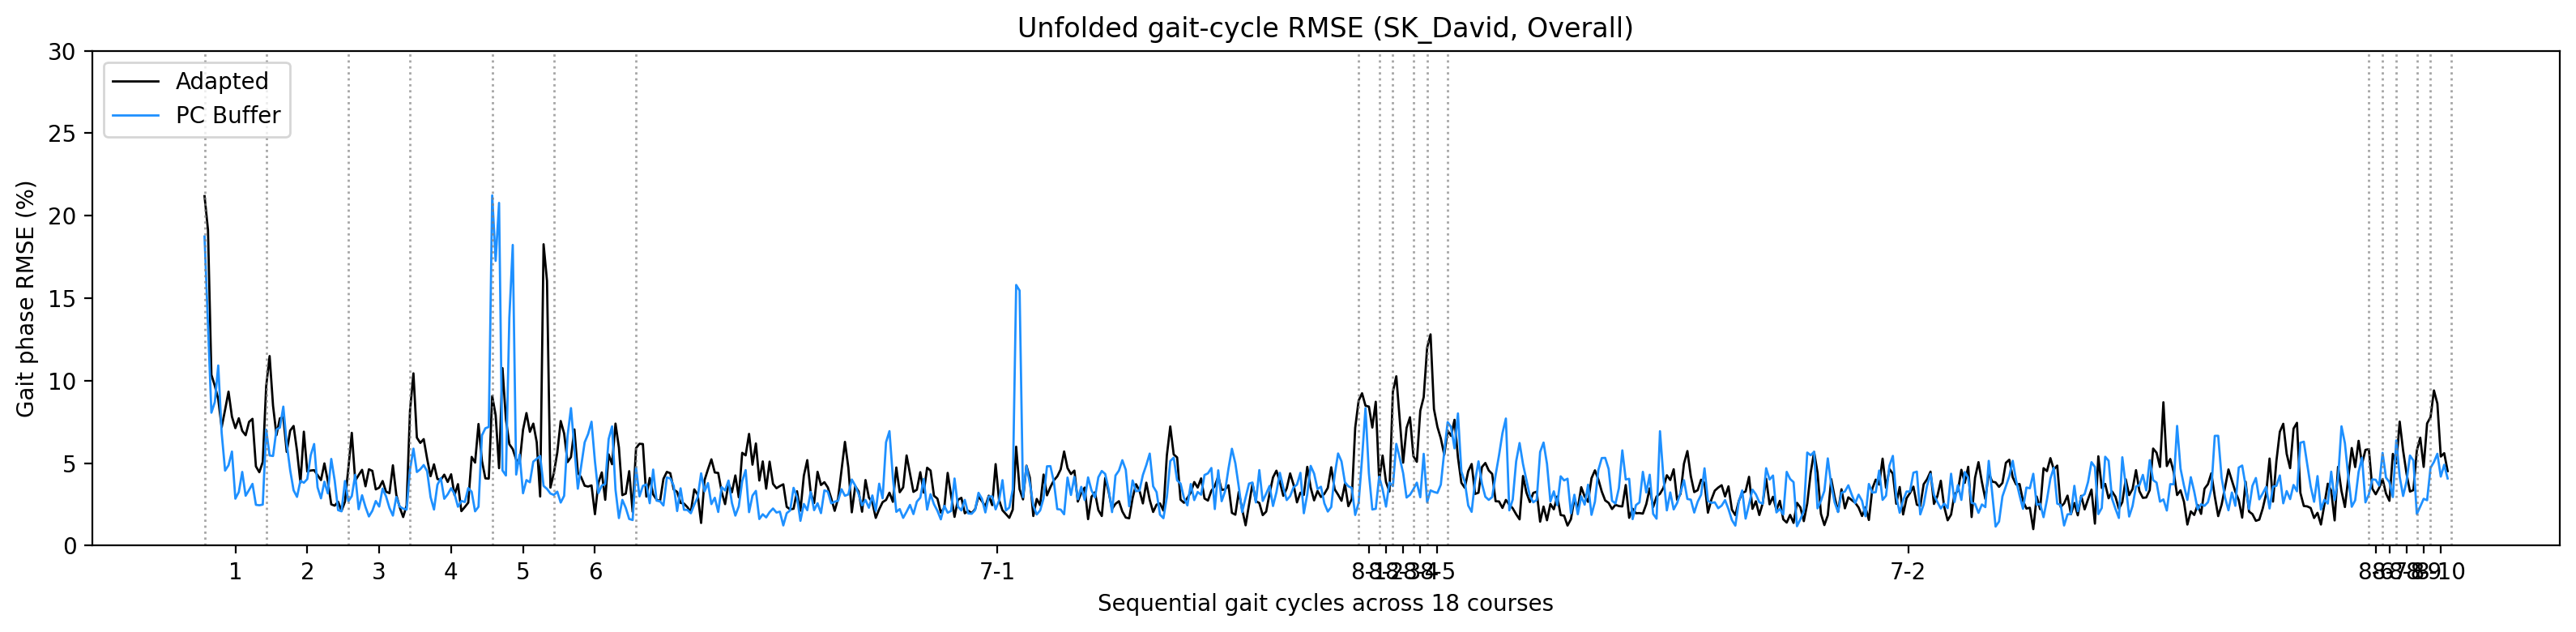

In [129]:
subject = 'SK_David'

plot_gc_rmses(
    segments_condition[1:],
    gc_rmse_R['adapted'][subject], gc_rmse_L['adapted'][subject],
    gc_rmse_R['pc_buffer'][subject], gc_rmse_L['pc_buffer'][subject],
    side='Overall'
)

Adapted RMSE avg across all tasks: 8.14 %
PC Buffer RMSE avg across all tasks: 6.47 %


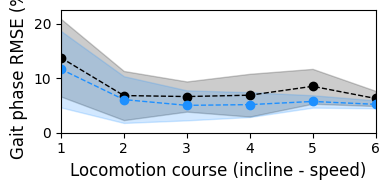

Subjects where adapted RMSE < pc_buffer RMSE (averaged across all courses and sides):

Condition: LG_Diff
SK_Itak: adapted=4.0, pc_buffer=4.8, difference=-0.857

Condition: RA_Same
SK_Maria: adapted=2.7, pc_buffer=4.6, difference=-1.984
SK_Crystal: adapted=4.7, pc_buffer=4.8, difference=-0.088

Condition: RA_Diff
SK_Itak: adapted=5.2, pc_buffer=5.3, difference=-0.056

Condition: RD_Same
SK_Rajiv: adapted=5.3, pc_buffer=6.1, difference=-0.829
SK_Itak: adapted=4.9, pc_buffer=5.7, difference=-0.772
SK_Crystal: adapted=4.8, pc_buffer=5.6, difference=-0.791
SK_Cole: adapted=5.3, pc_buffer=6.0, difference=-0.719

Condition: RD_Diff
SK_Itak: adapted=8.1, pc_buffer=8.4, difference=-0.296

--- TWO-WAY ANOVA RESULTS ---
                            sum_sq    df          F        PR(>F)
C(Method)               189.917980   1.0  39.551062  1.586947e-08
C(Condition)             62.339110   4.0   3.245583  1.607418e-02
C(Method):C(Condition)   29.037160   4.0   1.511772  2.066324e-01
Residual        

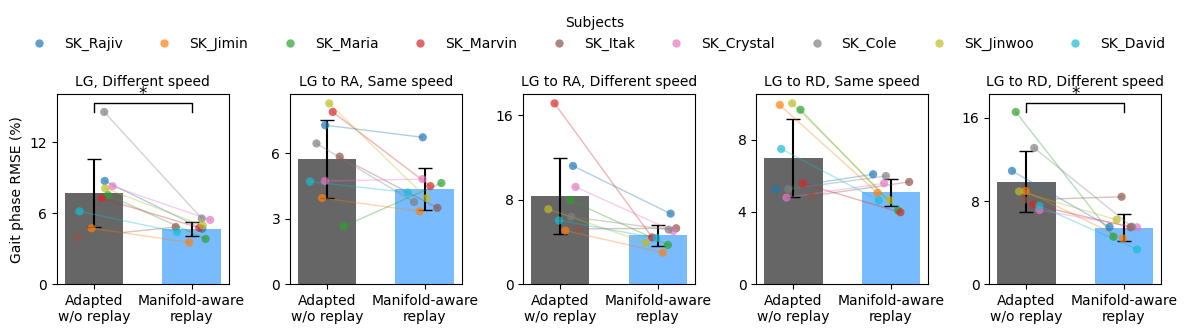

Subjects where adapted RMSE < pc_buffer RMSE (averaged across all courses and sides):

Condition: LG_Diff
SK_Itak: adapted=0.4, pc_buffer=0.6, difference=-0.113

Condition: RA_Same
SK_Maria: adapted=0.8, pc_buffer=1.2, difference=-0.400
SK_Crystal: adapted=1.1, pc_buffer=1.4, difference=-0.286
SK_David: adapted=1.1, pc_buffer=1.2, difference=-0.098

Condition: RA_Diff

Condition: RD_Same
SK_Rajiv: adapted=0.5, pc_buffer=0.6, difference=-0.092
SK_Marvin: adapted=0.3, pc_buffer=0.4, difference=-0.103
SK_Itak: adapted=0.5, pc_buffer=0.6, difference=-0.061
SK_Crystal: adapted=0.4, pc_buffer=0.5, difference=-0.050
SK_Cole: adapted=0.6, pc_buffer=0.7, difference=-0.121

Condition: RD_Diff

--- TWO-WAY ANOVA RESULTS ---
                           sum_sq    df          F        PR(>F)
C(Method)                2.446861   1.0  23.778454  5.395070e-06
C(Condition)            18.328634   4.0  44.529150  1.280460e-19
C(Method):C(Condition)   0.942600   4.0   2.290032  6.685775e-02
Residual         

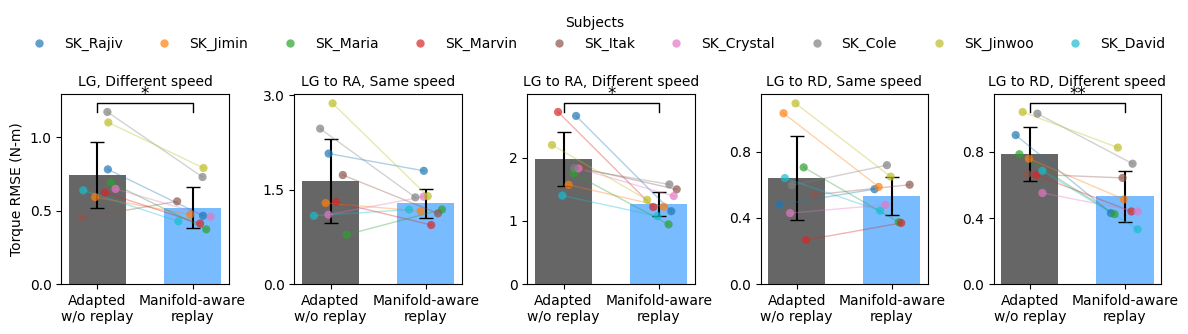

In [130]:
# adapted_rmse = np.mean([course_rmse_L['adapted'], course_rmse_R['adapted']], axis=0).tolist(); adapted_rmse_torque = np.mean([course_rmse_torque_L['adapted'], course_rmse_torque_R['adapted']], axis=0).tolist()
# pc_buffer_rmse = np.mean([course_rmse_L['pc_buffer'], course_rmse_R['pc_buffer']], axis=0).tolist(); pc_buffer_rmse_torque = np.mean([course_rmse_torque_L['pc_buffer'], course_rmse_torque_R['pc_buffer']], axis=0).tolist()

plot_course_rmses(segments_condition[1:], subjects, course_rmse_R['adapted'], course_rmse_L['adapted'], course_rmse_R['pc_buffer'], course_rmse_L['pc_buffer'],
                    course_rmse_torque_R['adapted'], course_rmse_torque_L['adapted'], course_rmse_torque_R['pc_buffer'], course_rmse_torque_L['pc_buffer'])

plot_course_rmses_2(subjects, course_rmse_R['adapted'],	course_rmse_L['adapted'], course_rmse_R['pc_buffer'], course_rmse_L['pc_buffer'], data='gc')

plot_course_rmses_2(subjects, course_rmse_torque_R['adapted'],	course_rmse_torque_L['adapted'], course_rmse_torque_R['pc_buffer'], course_rmse_torque_L['pc_buffer'], data='torque')


Condition: LG - Different Speed
      H SK_Cole L 13 score=21.846 4 4
      M SK_Itak L 13 score=6.715 4 4
      L SK_Itak R 7 score=2.452 6 6

Condition: LG to RA - Same Speed
      H SK_Marvin R 8 score=13.125 4 4
      M SK_Marvin L 15 score=4.995 7 7
      L SK_Maria L 8 score=1.822 5 5

Condition: LG to RA - Different Speed
      H SK_Marvin R 9 score=28.891 6 6
      M SK_Itak L 14 score=6.677 4 4
      L SK_Jimin L 14 score=3.459 4 4

Condition: LG to RD - Same Speed
      H SK_Jimin R 10 score=16.485 4 4
      M SK_David R 17 score=5.859 6 6
      L SK_Cole R 17 score=3.433 6 6

Condition: LG to RD - Different Speed
      H SK_Maria L 16 score=26.361 5 5
      M SK_David L 11 score=8.661 6 6
      L SK_Jimin L 11 score=2.573 6 7


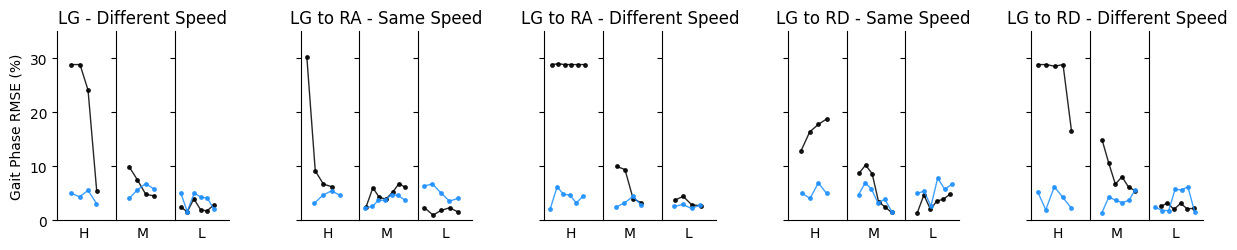


Condition: LG - Different Speed
      H SK_Jinwoo R 7 score=2.347 6 6
      M SK_Jimin L 7 score=0.800 6 6
      L SK_David L 13 score=0.165 4 4

Condition: LG to RA - Same Speed
      H SK_Cole L 15 score=5.593 5 7
      M SK_Jinwoo L 8 score=1.299 4 4
      L SK_Maria R 8 score=0.356 4 4

Condition: LG to RA - Different Speed
      H SK_Rajiv L 9 score=5.391 6 6
      M SK_Jimin L 9 score=1.767 7 5
      L SK_David L 14 score=0.468 4 4

Condition: LG to RD - Same Speed
      H SK_Jinwoo R 17 score=1.611 6 6
      M SK_Jimin L 10 score=0.576 4 4
      L SK_Marvin L 17 score=0.179 5 7

Condition: LG to RD - Different Speed
      H SK_Jinwoo R 11 score=2.082 6 6
      M SK_Maria L 11 score=0.900 6 7
      L SK_Marvin L 16 score=0.179 5 4


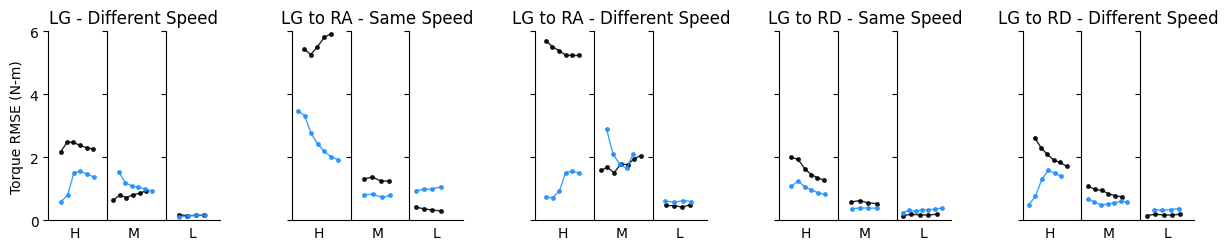

In [15]:
process_representative_rmse(subjects, gc_rmse_R, gc_rmse_L, hs_indices, data='gc')
process_representative_rmse(subjects, torque_rmse_R, torque_rmse_L, hs_indices, data='torque')

[SK_Rajiv] Aggregated total rows * 4: 576
[SK_Rajiv] Total replayed task labels counted: 576
[SK_Jimin] Aggregated total rows * 4: 576
[SK_Jimin] Total replayed task labels counted: 576
[SK_Maria] Aggregated total rows * 4: 576
[SK_Maria] Total replayed task labels counted: 576
[SK_Marvin] Aggregated total rows * 4: 576
[SK_Marvin] Total replayed task labels counted: 576


[SK_Itak] Aggregated total rows * 4: 576
[SK_Itak] Total replayed task labels counted: 576
[SK_Crystal] Aggregated total rows * 4: 572
[SK_Crystal] Total replayed task labels counted: 572
[SK_Cole] Aggregated total rows * 4: 576
[SK_Cole] Total replayed task labels counted: 573
[SK_Jinwoo] Aggregated total rows * 4: 576
[SK_Jinwoo] Total replayed task labels counted: 576
[SK_David] Aggregated total rows * 4: 576
[SK_David] Total replayed task labels counted: 575


,task_label,x,y,percentage_avg,percentage_std
0,"[-10.0, 0.3]",-10.0,0.3,10.4,4.5
1,"[0.0, 0.3]",0.0,0.3,28.0,12.9
2,"[10.0, 0.3]",10.0,0.3,7.1,5.5
3,"[-10.0, 0.7]",-10.0,0.7,20.7,10.7
4,"[0.0, 0.7]",0.0,0.7,9.4,8.8
5,"[10.0, 0.7]",10.0,0.7,24.5,7.8


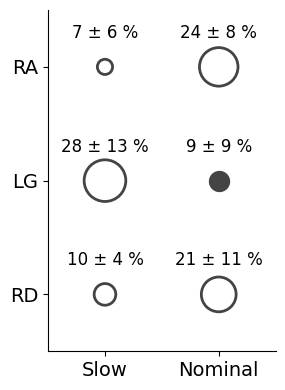

In [16]:
import ast
from collections import Counter

course_specs = [
    ('7_1', 'LG_slow'),
    # ('7_2', 'LG_fast'),
]
condition = 'pc_buffer'

side_to_target = {
    'L': 'replayed_bins_task_label_L',
    'R': 'replayed_bins_task_label_R',
}

def parse_task_labels(value):
    if pd.isna(value):
        return []

    if isinstance(value, (np.ndarray, pd.Series)):
        arr = np.asarray(value, dtype=float)
        if arr.size == 0:
            return []
        arr = arr.reshape(-1, 2)
        return [tuple(np.round(row, 3)) for row in arr]

    if isinstance(value, str):
        text = value.strip()
        if text in ('', '[]'):
            return []

        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, (list, tuple, np.ndarray, pd.Series)):
                arr = np.asarray(parsed, dtype=float)
                if arr.ndim == 1 and arr.size == 2:
                    return [tuple(np.round(arr, 3))]
                if arr.ndim == 2 and arr.shape[1] == 2:
                    return [tuple(np.round(row, 3)) for row in arr]
        except (ValueError, SyntaxError):
            pass

        flat = np.fromstring(
            text.replace('[', ' ').replace(']', ' ').replace('\\n', ' '),
            sep=' '
        )
        if flat.size >= 2 and flat.size % 2 == 0:
            return [tuple(np.round(row, 3)) for row in flat.reshape(-1, 2)]

        return []

    if isinstance(value, (list, tuple)):
        arr = np.asarray(value, dtype=float)
        if arr.ndim == 1 and arr.size == 2:
            return [tuple(np.round(arr, 3))]
        if arr.ndim == 2 and arr.shape[1] == 2:
            return [tuple(np.round(row, 3)) for row in arr]

    return []

# Collect per-subject replay-label counts first.
subject_counters = []
subject_totals = []

for subject in subjects:
    root_folder = f'/home/metamobility5/Changseob/proj-online_adaptation_GPE/analysis-main_exp/{subject}'
    all_replayed_task_labels = []
    total_slots = 0

    for course, inc in course_specs:
        for side, target_col in side_to_target.items():
            file_path = f'{root_folder}/{subject}-{condition}-{course}_{inc}-pc_{side}.csv'
            pc_df = load_PC_buffer_data(file_path)
            total_slots += len(pc_df) * 4

            if target_col not in pc_df.columns:
                raise KeyError(f"Column '{target_col}' not found in {file_path}. Available columns: {pc_df.columns.tolist()}")

            parsed_labels = []
            for value in pc_df[target_col]:
                parsed_labels.extend(parse_task_labels(value))

            all_replayed_task_labels.extend(parsed_labels)

    counter = Counter(all_replayed_task_labels)
    subject_counters.append(counter)
    subject_totals.append(sum(counter.values()))

    print(f"[{subject}] Aggregated total rows * 4: {total_slots}")
    print(f"[{subject}] Total replayed task labels counted: {subject_totals[-1]}")

# Build a canonical label set so every subject uses the same column order.
canonical_labels = sorted(
    set().union(*(set(c.keys()) for c in subject_counters)),
    key=lambda t: (t[1], t[0])
    )

if len(canonical_labels) == 0:
    raise ValueError('No replayed task labels found in the selected files.')

percentages = np.zeros((len(subjects), len(canonical_labels)), dtype=float)
for subj_idx, counter in enumerate(subject_counters):
    total = subject_totals[subj_idx]
    if total == 0:
        continue
    for col_idx, label in enumerate(canonical_labels):
        percentages[subj_idx, col_idx] = counter.get(label, 0) / total * 100

percentage_avg = np.mean(percentages, axis=0)
percentage_std = np.std(percentages, axis=0)

task_label_count_df = pd.DataFrame({
    'task_label_tuple': canonical_labels,
    'percentage_avg': np.round(percentage_avg, 1),
    'percentage_std': np.round(percentage_std, 1),
})
task_label_count_df[['x', 'y']] = pd.DataFrame(
    task_label_count_df['task_label_tuple'].tolist(),
    index=task_label_count_df.index
)
task_label_count_df['task_label'] = task_label_count_df['task_label_tuple'].apply(
    lambda v: f'[{v[0]:.1f}, {v[1]:.1f}]'
 )
display(task_label_count_df[['task_label', 'x', 'y', 'percentage_avg', 'percentage_std']])

# In this dataset: x=incline (3 levels), y=speed (2 levels).
incline_vals = sorted(task_label_count_df['x'].unique().tolist())
speed_vals = sorted(task_label_count_df['y'].unique().tolist())

if len(incline_vals) != 3 or len(speed_vals) != 2:
    raise ValueError(
        f'Expected a 3x2 incline-speed grid but found {len(incline_vals)} inclines and {len(speed_vals)} speeds: '
        f'incline={incline_vals}, speed={speed_vals}'
    )

speed_to_plot = {speed_vals[0]: 1, speed_vals[1]: 2}
speed_to_name = {speed_vals[0]: 'Slow', speed_vals[1]: 'Nominal'}
incline_to_plot = {inc: i for i, inc in enumerate(incline_vals)}
incline_to_name = {incline_vals[0]: 'RD', incline_vals[1]: 'LG', incline_vals[2]: 'RA'}

# Marker area scaling in points^2: proportional to replay percentage.
s_min = 120
s_max = 900
p_min = float(task_label_count_df['percentage_avg'].min())
p_max = float(task_label_count_df['percentage_avg'].max())

def marker_size_from_pct(pct):
    if np.isclose(p_min, p_max):
        return (s_min + s_max) / 2
    return s_min + (pct - p_min) * (s_max - s_min) / (p_max - p_min)

points = []
for _, row in task_label_count_df.iterrows():
    pct = float(row['percentage_avg'])
    points.append(
        (
            speed_to_plot[row['y']],
            incline_to_plot[row['x']],
            f"{row['percentage_avg']:.0f} ± {row['percentage_std']:.0f} %",
            marker_size_from_pct(pct),
            row['x'],
            row['y'],
        )
    )

# Choose the LG-Nominal-like center: middle incline and faster speed.
center_incline = incline_vals[1]
center_speed = speed_vals[1]
center_point = None
peripheral_points = []
for x_plot, y_plot, label, marker_size, raw_incline, raw_speed in points:
    if np.isclose(raw_incline, center_incline) and np.isclose(raw_speed, center_speed):
        center_point = (x_plot, y_plot, label, marker_size)
    else:
        peripheral_points.append((x_plot, y_plot, label, marker_size))

if center_point is None and peripheral_points:
    center_point = peripheral_points.pop(0)

fig, ax = plt.subplots(figsize=(5, 4))

for x, y, label, marker_size in peripheral_points:
    ax.scatter(x, y, s=marker_size, edgecolor='#444444', facecolor='none', linestyle='-', linewidth=2, zorder=3)
    ax.text(x, y + 0.3, label, ha='center', va='center', fontsize=12)

if center_point is not None:
    ax.scatter(center_point[0], center_point[1], s=center_point[3], color='#444444', zorder=3)
    ax.text(center_point[0], center_point[1] + 0.3, center_point[2], ha='center', va='center', fontsize=12)

ax.set_xticks([1, 2])
ax.set_xticklabels([speed_to_name[speed_vals[0]], speed_to_name[speed_vals[1]]], fontsize=14)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels([incline_to_name[incline_vals[0]], incline_to_name[incline_vals[1]], incline_to_name[incline_vals[2]]], fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim(0.5, 2.5)
ax.set_ylim(-0.5, 2.5)
ax.set_aspect('equal')
plt.tight_layout()
plt.rcParams['pdf.fonttype'] = 42
plt.savefig('Replayed_percent_slow.pdf', dpi=300)
plt.show()

In [17]:
import ast

course_specs = [
	('7_1', 'LG_slow'),
	# ('7_2', 'LG_fast'),
]
condition = 'pc_buffer'
percentages = np.zeros((len(subjects), 6))

for subj_idx, subject in enumerate(subjects):

	root_folder = f'/home/metamobility5/Changseob/proj-online_adaptation_GPE/analysis-main_exp/{subject}'
	side_to_target = {
		'L': 'replayed_bins_task_label_L',
		'R': 'replayed_bins_task_label_R',
	}


	def parse_task_labels(value):
		if pd.isna(value):
			return []

		if isinstance(value, (np.ndarray, pd.Series)):
			arr = np.asarray(value, dtype=float)
			if arr.size == 0:
				return []
			arr = arr.reshape(-1, 2)
			return [tuple(np.round(row, 3)) for row in arr]

		if isinstance(value, str):
			text = value.strip()
			if text in ('', '[]'):
				return []

			try:
				parsed = ast.literal_eval(text)
				if isinstance(parsed, (list, tuple, np.ndarray, pd.Series)):
					arr = np.asarray(parsed, dtype=float)
					if arr.ndim == 1 and arr.size == 2:
						return [tuple(np.round(arr, 3))]
					if arr.ndim == 2 and arr.shape[1] == 2:
						return [tuple(np.round(row, 3)) for row in arr]
			except (ValueError, SyntaxError):
				pass

			flat = np.fromstring(
				text.replace('[', ' ').replace(']', ' ').replace('\n', ' '),
				sep=' '
			)
			if flat.size >= 2 and flat.size % 2 == 0:
				return [tuple(np.round(row, 3)) for row in flat.reshape(-1, 2)]

			return []

		if isinstance(value, (list, tuple)):
			arr = np.asarray(value, dtype=float)
			if arr.ndim == 1 and arr.size == 2:
				return [tuple(np.round(arr, 3))]
			if arr.ndim == 2 and arr.shape[1] == 2:
				return [tuple(np.round(row, 3)) for row in arr]

		return []

	all_replayed_task_labels = []
	source_summary = []
	total_slots = 0

	for course, inc in course_specs:
		for side, target_col in side_to_target.items():
			file_path = f'{root_folder}/{subject}-{condition}-{course}_{inc}-pc_{side}.csv'
			pc_df = load_PC_buffer_data(file_path)

			total_slots += len(pc_df) * 4

			if target_col not in pc_df.columns:
				raise KeyError(f"Column '{target_col}' not found in {file_path}. Available columns: {pc_df.columns.tolist()}")

			parsed_labels = []
			for value in pc_df[target_col]:
				parsed_labels.extend(parse_task_labels(value))

			all_replayed_task_labels.extend(parsed_labels)
			source_summary.append({
				'course': course,
				'incline_speed': inc,
				'side': side,
				'n_rows': len(pc_df),
				'n_replayed_labels': len(parsed_labels),
			})

	task_label_count_df = (
		pd.Series(all_replayed_task_labels, name='task_label')
		.value_counts()
		.rename_axis('task_label')
		.reset_index(name='replay_count')
	)

	if not task_label_count_df.empty:
		task_label_count_df[['x', 'y']] = pd.DataFrame(
			task_label_count_df['task_label'].tolist(),
			index=task_label_count_df.index
		)
		task_label_count_df['task_label'] = task_label_count_df['task_label'].apply(
			lambda v: f'[{v[0]:.1f}, {v[1]:.1f}]'
		)
		task_label_count_df = task_label_count_df[['task_label', 'x', 'y', 'replay_count']]

	source_summary_df = pd.DataFrame(source_summary)

	print(f"Aggregated total rows * 4: {total_slots}")
	print(f"Total replayed task labels counted: {len(all_replayed_task_labels)}")
	# display(source_summary_df)
	if not task_label_count_df.empty:
		task_label_count_df = task_label_count_df.copy()
		total_replay_count = task_label_count_df['replay_count'].sum()
		task_label_count_df['percentage'] = (
			task_label_count_df['replay_count'] / total_replay_count * 100
		).round(1)

	percentages[subj_idx] = task_label_count_df['percentage'].values  # Assuming we want the top 6 task labels

display(task_label_count_df)

percentage_avg = np.mean(percentages, axis=0)
percentage_std = np.std(percentages, axis=0)

import matplotlib.pyplot as plt

# 1. Define the labels and coordinates
speeds = {'Slow': 1, 'Nominal': 2}
terrains = {'RD': 0, 'LG': 1, 'RA': 2}

# 2. Data points from your image
# Format: (x_coord, y_coord, label_text)
points = [
    (speeds['Slow'], terrains['RA'], f"{percentage_avg[5]:.0f} ± {percentage_std[5]:.0f} %"),
    (speeds['Nominal'], terrains['RA'], f"{percentage_avg[2]:.0f} ± {percentage_std[2]:.0f} %"),
    (speeds['Nominal'], terrains['LG'], f"{percentage_avg[0]:.0f} ± {percentage_std[0]:.0f} %"),
    (speeds['Nominal'], terrains['RD'], f"{percentage_avg[4]:.0f} ± {percentage_std[4]:.0f} %"),
    (speeds['Slow'], terrains['RD'], f"{percentage_avg[1]:.0f} ± {percentage_std[1]:.0f} %"),
]
center_point = (speeds['Slow'], terrains['LG'], f"{percentage_avg[3]:.0f} ± {percentage_std[3]:.0f} %")

# 3. Create the plot
fig, ax = plt.subplots(figsize=(6, 4.5))

# Plot the red peripheral dots
for x, y, label in points:
    ax.scatter(x, y, s=300, color='firebrick', zorder=3)
    ax.text(x+0.3, y+0.2, label, ha='right', va='center', fontsize=12)

# Plot the dark grey center dot
ax.scatter(center_point[0], center_point[1], s=600, color='#444444', zorder=3)
ax.text(center_point[0]+0.3, center_point[1]+0.2, center_point[2], 
        ha='right', va='center', fontsize=12,)

# 5. Styling the axes to match your diagram
ax.set_xticks([1, 2])
ax.set_xticklabels(['Slow', 'Nominal'], fontsize=14)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['RD', 'LG', 'RA'], fontsize=14)

# Spine formatting (Arrows on axes)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim(0.5, 2.5)
ax.set_ylim(-0.5, 2.5)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


Aggregated total rows * 4: 576
Total replayed task labels counted: 576
Aggregated total rows * 4: 576
Total replayed task labels counted: 576
Aggregated total rows * 4: 576
Total replayed task labels counted: 576
Aggregated total rows * 4: 576
Total replayed task labels counted: 576
Aggregated total rows * 4: 576
Total replayed task labels counted: 576
Aggregated total rows * 4: 572
Total replayed task labels counted: 572
Aggregated total rows * 4: 576
Total replayed task labels counted: 573


ValueError: could not broadcast input array from shape (5,) into shape (6,)

Overall silhouette score (L): 0.1798
-10.0_0.3: 0.1290
-10.0_0.7: 0.0288
0.0_0.3: -0.1863
0.0_0.7: 0.2981
10.0_0.3: 0.5502
10.0_0.7: 0.2900

Overall silhouette score (R): 0.1618
-10.0_0.3: 0.1616
-10.0_0.7: 0.3067
0.0_0.3: -0.1856
0.0_0.7: -0.1406
10.0_0.3: 0.4634
10.0_0.7: 0.3975


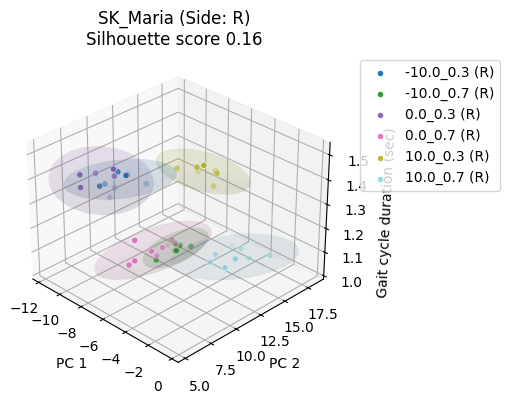

In [30]:
# --- USER SETTINGS ---
subject = 'SK_Maria'
side = 'R'  # Change to 'L' or 'R' here
# ---------------------
import plotly.graph_objects as go

cmap = plt.get_cmap("tab20", 18)
palette = [
    "#{:02x}{:02x}{:02x}".format(
        int(255 * cmap(i)[0]), int(255 * cmap(i)[1]), int(255 * cmap(i)[2])
    )
    for i in range(18)
]

def _to_xyz(points_3d, disc=False):
    parsed = []
    for p in points_3d:
        if isinstance(p, str):
            # robust for both "[x y z]" and "[x, y, z]"
            arr = np.fromstring(p.strip("()").replace(",", " "), sep=" ") if disc else np.fromstring(p.strip("[]").replace(",", " "), sep=" ")
        else:
            arr = np.asarray(p, dtype=float).ravel()
        if arr.size >= 3 and np.all(np.isfinite(arr[:3])):
            parsed.append(arr[:3])
    return np.array(parsed, dtype=float)

pts_L = _to_xyz(input_reduced_L['pc_buffer'][subject])
pts_R = _to_xyz(input_reduced_R['pc_buffer'][subject])
pts_L_disc = _to_xyz(grid_key_L['pc_buffer'][subject], disc=True)
pts_R_disc = _to_xyz(grid_key_R['pc_buffer'][subject], disc=True)

# Build labels and convert to numpy arrays (important for boolean masking)
labels_L = np.array([f"{inc_idx_L['pc_buffer'][subject][i]}_{spd_idx_L['pc_buffer'][subject][i]}" for i in range(len(spd_idx_L['pc_buffer'][subject]))], dtype=str)
labels_R = np.array([f"{inc_idx_R['pc_buffer'][subject][i]}_{spd_idx_R['pc_buffer'][subject][i]}" for i in range(len(spd_idx_R['pc_buffer'][subject]))], dtype=str)

all_labels = np.concatenate([labels_L, labels_R])
unique_tasks = np.unique(all_labels)

task_to_color = {task: palette[i % len(palette)] for i, task in enumerate(unique_tasks)}

fig = go.Figure()

for side, pts, labels, symbol in [
    ("L", pts_L, labels_L, "circle"),
    ("R", pts_R, labels_R, "diamond"),
]:
    n = min(len(pts), len(labels))
    if n == 0:
        continue

    pts_side = pts[:n]
    labels_side = labels[:n]

    for task in unique_tasks:
        mask = labels_side == task
        if not np.any(mask):
            continue

        idx = np.where(mask)[0]
        color = task_to_color[task]

        fig.add_trace(
            go.Scatter3d(
                x=pts_side[mask, 0],
                y=pts_side[mask, 1],
                z=pts_side[mask, 2],
                mode="markers+text",
                # text=idx.astype(str),
                textposition="top center",
                name=f"{task} ({side})",
                marker=dict(size=6, color=color, symbol=symbol),
            )
        )

fig.update_layout(
    title="Sequential 3D points with index labels",
    scene=dict(xaxis_title="PC 1", yaxis_title="PC 2", zaxis_title="Gait cycle duration (sec)"),
    width=500,
    height=500,
)
from sklearn.metrics import silhouette_samples, silhouette_score

# Categorize pts_L according to label_L
categorized_pts_L = {
    label: pts_L[labels_L == label]
    for label in np.unique(labels_L)
}
categorized_pts_R = {
    label: pts_R[labels_R == label]
    for label in np.unique(labels_R)
}

sample_silhouette_L = silhouette_samples(pts_L, labels_L)
silhouette_per_label_L = {
    label: float(np.mean(sample_silhouette_L[labels_L == label]))
    for label in np.unique(labels_L)
}
overall_silhouette_L = float(silhouette_score(pts_L, labels_L))

sample_silhouette_R = silhouette_samples(pts_R, labels_R)
silhouette_per_label_R = {
    label: float(np.mean(sample_silhouette_R[labels_R == label]))
    for label in np.unique(labels_R)
}
overall_silhouette_R = float(silhouette_score(pts_R, labels_R))

print(f"Overall silhouette score (L): {overall_silhouette_L:.4f}")
for label, score in silhouette_per_label_L.items():
    print(f"{label}: {score:.4f}")

print(f"\nOverall silhouette score (R): {overall_silhouette_R:.4f}")
for label, score in silhouette_per_label_R.items():
    print(f"{label}: {score:.4f}")


CHI2_99_DF3 = 11.344866730144373  # chi2.ppf(0.99, df=3)
CHI2_90_DF3 = 6.251387908707872  # chi2.ppf(0.90, df=3)
def _add_confidence_ellipsoid(fig, pts_cluster, color, name, confidence_scale=np.sqrt(CHI2_90_DF3)):
    pts_cluster = np.asarray(pts_cluster, dtype=float)
    if pts_cluster.shape[0] < 4:
        return

    center = pts_cluster.mean(axis=0)
    cov = np.cov(pts_cluster.T)

    if not np.all(np.isfinite(cov)):
        return

    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.clip(eigvals, 1e-9, None)
    radii = confidence_scale * np.sqrt(eigvals)

    u = np.linspace(0, 2 * np.pi, 36)
    v = np.linspace(0, np.pi, 18)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    sphere = np.stack([x, y, z], axis=0).reshape(3, -1)

    ellipsoid = (eigvecs @ np.diag(radii) @ sphere).reshape(3, len(u), len(v))
    xe = ellipsoid[0] + center[0]
    ye = ellipsoid[1] + center[1]
    ze = ellipsoid[2] + center[2]

    fig.add_trace(
        go.Surface(
            x=xe,
            y=ye,
            z=ze,
            showscale=False,
            opacity=0.18,
            surfacecolor=np.zeros_like(xe),
            colorscale=[[0, color], [1, color]],
            name=name,
            hoverinfo="skip",
            showlegend=False,
        )
    )

for side, categorized_pts in [("L", categorized_pts_L), ("R", categorized_pts_R)]:
    for label, pts_cluster in categorized_pts.items():
        _add_confidence_ellipsoid(
            fig,
            pts_cluster,
            task_to_color[label],
            f"{label} ({side}) 99% ellipsoid",
        )

fig.update_layout(
    title="Sequential 3D points with index labels and 99% ellipsoids"
)

fig.show()
# Keep only one fig.show() in the cell, after this block.

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np



# 1. Data Selection Logic
if side.upper() == 'R':
    pts = pts_R
    pts_disc = pts_R_disc
    labels = labels_R
    cat_pts = categorized_pts_R
    marker = 'o'  # Diamond for Right
else:
    pts = pts_L
    pts_disc = pts_L_disc
    labels = labels_L
    cat_pts = categorized_pts_L
    marker = 'o'  # Circle for Left

# Re-calculate unique tasks for this side only
unique_tasks = np.unique(labels)
cmap = plt.get_cmap("tab20", len(unique_tasks))
task_to_color = {task: cmap(i) for i, task in enumerate(unique_tasks)}

# 2. Setup Figure and 3D Axis
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')

def _add_mpl_ellipsoid(ax, pts_cluster, color, confidence_scale=np.sqrt(11.3448)):
    pts_cluster = np.asarray(pts_cluster, dtype=float)
    if pts_cluster.shape[0] < 4: return
    
    center = pts_cluster.mean(axis=0)
    cov = np.cov(pts_cluster.T)
    if not np.all(np.isfinite(cov)): return

    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.clip(eigvals, 1e-9, None)
    radii = confidence_scale * np.sqrt(eigvals)

    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 15)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    
    sphere = np.stack([x, y, z], axis=0).reshape(3, -1)
    ellipsoid = (eigvecs @ np.diag(radii) @ sphere).reshape(3, *x.shape)
    
    ax.plot_surface(
        ellipsoid[0] + center[0], 
        ellipsoid[1] + center[1], 
        (ellipsoid[2] + center[2])/100, 
        color=color, alpha=0.08, linewidth=0
    )

# 3. Plot Scatter Points for the selected side
n = min(len(pts), len(labels))
pts_final = pts[:n]
pts_final_disc = pts_disc[:n]
labels_final = labels[:n]

for task in unique_tasks:
    mask = labels_final == task
    if not np.any(mask): continue

    ax.scatter(
        pts_final[mask, 0], 
        pts_final[mask, 1], 
        pts_final[mask, 2]/100,
        color=task_to_color[task],
        marker=marker,
        s=20,
        edgecolors='white',
        linewidth=0.5,
        label=f"{task} ({side})"
    )
    # ax.scatter(
    #     pts_final_disc[mask, 0]*2, 
    #     pts_final_disc[mask, 1]*2, 
    #     pts_final_disc[mask, 2]*10/100,
    #     color=task_to_color[task],
    #     marker='x',
    #     s=50,
    #     linewidth=0.75,
    #     label=f"{task} ({side})"
    # )

# 4. Add Ellipsoids for the selected side
for label, pts_cluster in cat_pts.items():
    _add_mpl_ellipsoid(ax, pts_cluster, task_to_color[label])

# 5. Final Formatting
if side == 'L':
    silhouette_score = overall_silhouette_L
else:
    silhouette_score = overall_silhouette_R

ax.set_title(f"{subject} (Side: {side})\nSilhouette score {silhouette_score:.2f}")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("Gait cycle duration (sec)")

# Legend management (only show one entry per task)
handles, plot_labels = ax.get_legend_handles_labels()
by_label = dict(zip(plot_labels, handles))
ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
ax.view_init(elev=30, azim=-45)
plt.tight_layout()
plt.show()

Silhouette scores for all valid cases (n=18):


,subject,side,silhouette
0,SK_Cole,L,-0.042002
1,SK_Cole,R,-0.045104
2,SK_Crystal,L,0.039858
3,SK_Crystal,R,0.046820
4,SK_David,L,-0.014195
5,SK_David,R,-0.046357
6,SK_Itak,L,0.215761
7,SK_Itak,R,-0.045197
8,SK_Jimin,L,0.048663
9,SK_Jimin,R,0.070939


Mean silhouette score: 0.0818
Std silhouette score: 0.0929
Selected representative cases from 18 subject-side combinations:


,rank,subject,side,silhouette,n_points,n_tasks
0,lowest,SK_David,R,-0.046357,48,6
1,median,SK_Jimin,R,0.070939,47,6
2,highest,SK_Itak,L,0.215761,44,6


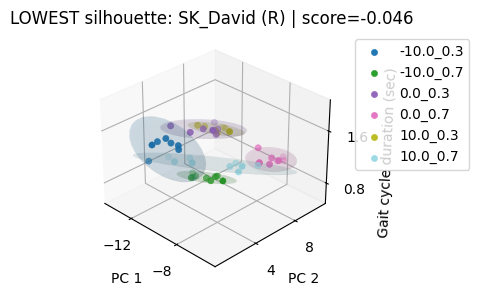

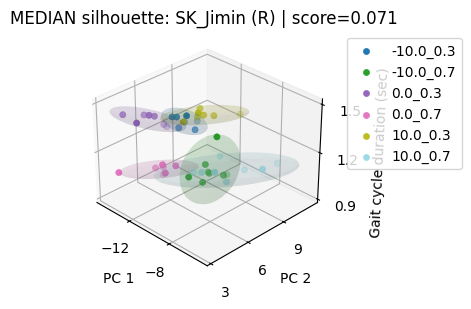

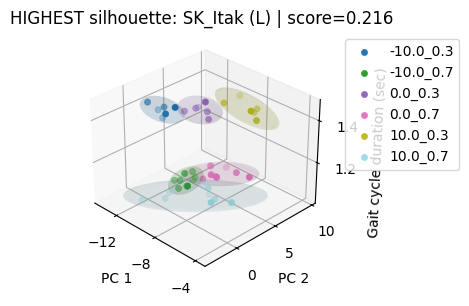

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import chi2
from sklearn.metrics import silhouette_score

# Collect all 18 subject-side cases and compute silhouette scores.
def _to_xyz_case(points_3d):
    parsed = []
    for p in points_3d:
        if isinstance(p, str):
            arr = np.fromstring(p.strip("[]").replace(",", " "), sep=" ")
        else:
            arr = np.asarray(p, dtype=float).ravel()
        if arr.size >= 3 and np.all(np.isfinite(arr[:3])):
            parsed.append(arr[:3])
    return np.asarray(parsed, dtype=float)

def _build_case(subject, side):
    if side == "L":
        pts = _to_xyz_case(input_reduced_L['pc_buffer'][subject])
        labels = np.array([
            f"{inc_idx_L['pc_buffer'][subject][i]}_{spd_idx_L['pc_buffer'][subject][i]}"
            for i in range(len(spd_idx_L['pc_buffer'][subject]))
        ], dtype=str)
    else:
        pts = _to_xyz_case(input_reduced_R['pc_buffer'][subject])
        labels = np.array([
            f"{inc_idx_R['pc_buffer'][subject][i]}_{spd_idx_R['pc_buffer'][subject][i]}"
            for i in range(len(spd_idx_R['pc_buffer'][subject]))
        ], dtype=str)

    n = min(len(pts), len(labels))
    pts = pts[:n]
    labels = labels[:n]

    if n < 4 or np.unique(labels).size < 2:
        return None

    score = float(silhouette_score(pts, labels))
    return {
        "subject": subject,
        "side": side,
        "score": score,
        "pts": pts,
        "labels": labels,
    }

all_cases = []
for subject in subjects:
    for side in ["L", "R"]:
        case = _build_case(subject, side)
        if case is not None:
            all_cases.append(case)

if len(all_cases) == 0:
    raise ValueError("No valid subject-side cases found for silhouette analysis.")

# Print all silhouette scores and summary stats.
score_table = pd.DataFrame([
    {
        "subject": case["subject"],
        "side": case["side"],
        "silhouette": case["score"],
    }
    for case in sorted(all_cases, key=lambda x: (x["subject"], x["side"]))
])

print(f"Silhouette scores for all valid cases (n={len(score_table)}):")
display(score_table)

score_values = score_table["silhouette"].to_numpy(dtype=float)
print(f"Mean silhouette score: {np.mean(score_values):.4f}")
print(f"Std silhouette score: {np.std(score_values):.4f}")

all_cases_sorted = sorted(all_cases, key=lambda x: x["score"])
mid_idx = len(all_cases_sorted) // 2
selected_cases = [
    ("lowest", all_cases_sorted[0]),
    ("median", all_cases_sorted[mid_idx]),
    ("highest", all_cases_sorted[-1]),
]

summary_df = pd.DataFrame([
    {
        "rank": rank_name,
        "subject": case["subject"],
        "side": case["side"],
        "silhouette": case["score"],
        "n_points": len(case["pts"]),
        "n_tasks": int(np.unique(case["labels"]).size),
    }
    for rank_name, case in selected_cases
])
print("Selected representative cases from 18 subject-side combinations:")
display(summary_df)

CHI2_90_DF3 = chi2.ppf(0.90, df=3)

# Plotly helper.
def _add_plotly_confidence_ellipsoid(fig, pts_cluster, color, confidence_scale=np.sqrt(CHI2_90_DF3)):
    pts_cluster = np.asarray(pts_cluster, dtype=float)
    if pts_cluster.shape[0] < 4:
        return

    center = pts_cluster.mean(axis=0)
    cov = np.cov(pts_cluster.T)
    if not np.all(np.isfinite(cov)):
        return

    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.clip(eigvals, 1e-9, None)
    radii = confidence_scale * np.sqrt(eigvals)

    u = np.linspace(0, 2 * np.pi, 32)
    v = np.linspace(0, np.pi, 16)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    sphere = np.stack([x, y, z], axis=0).reshape(3, -1)

    ellipsoid = (eigvecs @ np.diag(radii) @ sphere).reshape(3, len(u), len(v))
    xe = ellipsoid[0] + center[0]
    ye = ellipsoid[1] + center[1]
    ze = ellipsoid[2] + center[2]

    fig.add_trace(
        go.Surface(
            x=xe,
            y=ye,
            z=ze,
            showscale=False,
            opacity=0.16,
            surfacecolor=np.zeros_like(xe),
            colorscale=[[0, color], [1, color]],
            hoverinfo="skip",
            showlegend=False,
        )
    )

# Matplotlib helper.
def _add_mpl_confidence_ellipsoid(ax, pts_cluster, color, confidence_scale=np.sqrt(CHI2_90_DF3)):
    pts_cluster = np.asarray(pts_cluster, dtype=float)
    if pts_cluster.shape[0] < 4:
        return

    center = pts_cluster.mean(axis=0)
    cov = np.cov(pts_cluster.T)
    if not np.all(np.isfinite(cov)):
        return

    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.clip(eigvals, 1e-9, None)
    radii = confidence_scale * np.sqrt(eigvals)

    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 15)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    sphere = np.stack([x, y, z], axis=0).reshape(3, -1)

    ellipsoid = (eigvecs @ np.diag(radii) @ sphere).reshape(3, *x.shape)
    ax.plot_surface(
        ellipsoid[0] + center[0],
        ellipsoid[1] + center[1],
        (ellipsoid[2] + center[2]) / 100,
        color=color,
        alpha=0.10,
        linewidth=0,
    )

# Render selected cases in both Plotly and Matplotlib.
for rank_name, case in selected_cases:
    subject = case["subject"]
    side = case["side"]
    score = case["score"]
    pts = case["pts"]
    labels = case["labels"]

    unique_tasks = np.unique(labels)
    cmap = plt.get_cmap("tab20", len(unique_tasks))
    task_to_color_mpl = {task: cmap(i) for i, task in enumerate(unique_tasks)}
    task_to_color_hex = {
        task: "#{:02x}{:02x}{:02x}".format(
            int(255 * task_to_color_mpl[task][0]),
            int(255 * task_to_color_mpl[task][1]),
            int(255 * task_to_color_mpl[task][2]),
        )
        for task in unique_tasks
    }

    # Plotly figure.
    fig_plotly = go.Figure()
    for task in unique_tasks:
        mask = labels == task
        cluster = pts[mask]
        color_hex = task_to_color_hex[task]

        fig_plotly.add_trace(
            go.Scatter3d(
                x=cluster[:, 0],
                y=cluster[:, 1],
                z=cluster[:, 2],
                mode="markers",
                name=str(task),
                marker=dict(size=5, color=color_hex, symbol="circle" if side == "L" else "diamond"),
            )
        )
        _add_plotly_confidence_ellipsoid(fig_plotly, cluster, color_hex)

    fig_plotly.update_layout(
        title=f"{rank_name.upper()} silhouette: {subject} ({side}) | score={score:.3f}",
        scene=dict(
            xaxis_title="PC 1",
            yaxis_title="PC 2",
            zaxis_title="Gait cycle duration (sec)",
        ),
        width=700,
        height=550,
    )
    fig_plotly.show()

    # Matplotlib figure.
    fig_mpl = plt.figure(figsize=(4, 3))
    ax = fig_mpl.add_subplot(111, projection="3d")

    for task in unique_tasks:
        mask = labels == task
        cluster = pts[mask]
        color = task_to_color_mpl[task]

        ax.scatter(
            cluster[:, 0],
            cluster[:, 1],
            cluster[:, 2] / 100,
            color=color,
            marker="o",
            s=20,
            edgecolors=color,
            linewidth=0.4,
            label=str(task),
        )
        _add_mpl_confidence_ellipsoid(ax, cluster, color)

    handles, plot_labels = ax.get_legend_handles_labels()
    by_label = dict(zip(plot_labels, handles))
    ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_title(f"{rank_name.upper()} silhouette: {subject} ({side}) | score={score:.3f}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("Gait cycle duration (sec)")
    from matplotlib.ticker import MaxNLocator
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.zaxis.set_major_locator(MaxNLocator(nbins=2))
    ax.view_init(elev=30, azim=-45)

    plt.tight_layout()
    plt.rcParams['pdf.fonttype'] = 42

    if rank_name == "lowest":
        plt.savefig('Manifold_SK_L.pdf', dpi=300)
    elif rank_name == "highest":
        plt.savefig('Manifold_SK_H.pdf', dpi=300)
    elif rank_name == "median":
        plt.savefig('Manifold_SK_M.pdf', dpi=300)
    plt.show()

In [10]:
import plotly.graph_objects as go

cmap = plt.get_cmap("tab20", 18)
palette = [
    "#{:02x}{:02x}{:02x}".format(
        int(255 * cmap(i)[0]), int(255 * cmap(i)[1]), int(255 * cmap(i)[2])
    )
    for i in range(18)
]

def _to_xyz(points_3d):
    parsed = []
    for p in points_3d:
        if isinstance(p, str):
            # robust for both "[x y z]" and "[x, y, z]"
            arr = np.fromstring(p.strip("()").replace(",", " "), sep=" ")
        else:
            arr = np.asarray(p, dtype=float).ravel()
        if arr.size >= 3 and np.all(np.isfinite(arr[:3])):
            parsed.append(arr[:3])
    return np.array(parsed, dtype=float)

# pts_L = _to_xyz(input_reduced_L)
# pts_R = _to_xyz(input_reduced_R)
pts_L = _to_xyz(grid_key_L['pc_buffer'][subject])
pts_R = _to_xyz(grid_key_R['pc_buffer'][subject])

# Build labels and convert to numpy arrays (important for boolean masking)
labels_L = np.array([f"{inc_idx_L['pc_buffer'][subject][i]}_{spd_idx_L['pc_buffer'][subject][i]}" for i in range(len(spd_idx_L['pc_buffer'][subject]))], dtype=str)
labels_R = np.array([f"{inc_idx_R['pc_buffer'][subject][i]}_{spd_idx_R['pc_buffer'][subject][i]}" for i in range(len(spd_idx_R['pc_buffer'][subject]))], dtype=str)

all_labels = np.concatenate([labels_L, labels_R])
unique_tasks = np.unique(all_labels)

task_to_color = {task: palette[i % len(palette)] for i, task in enumerate(unique_tasks)}

fig = go.Figure()

for side, pts, labels, symbol in [
    ("L", pts_L, labels_L, "circle"),
    ("R", pts_R, labels_R, "diamond"),
]:
    n = min(len(pts), len(labels))
    if n == 0:
        continue

    pts_side = pts[:n]
    labels_side = labels[:n]

    for task in unique_tasks:
        mask = labels_side == task
        if not np.any(mask):
            continue

        idx = np.where(mask)[0]
        color = task_to_color[task]

        fig.add_trace(
            go.Scatter3d(
                x=pts_side[mask, 0],
                y=pts_side[mask, 1],
                z=pts_side[mask, 2],
                mode="markers+text",
                # text=idx.astype(str),
                textposition="top center",
                name=f"{task} ({side})",
                marker=dict(size=6, color=color, symbol=symbol),
            )
        )

fig.update_layout(
    title="Sequential 3D points with index labels",
    scene=dict(xaxis_title="PC 1 (/2)", yaxis_title="PC 2 (/2)", zaxis_title="Gait cycle duration (sec) (/10)"),
    width=1500,
    height=1000,
)
fig.show()

# Categorize points by task and calculate shiloutte score
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels_encoded = le.fit_transform(all_labels)

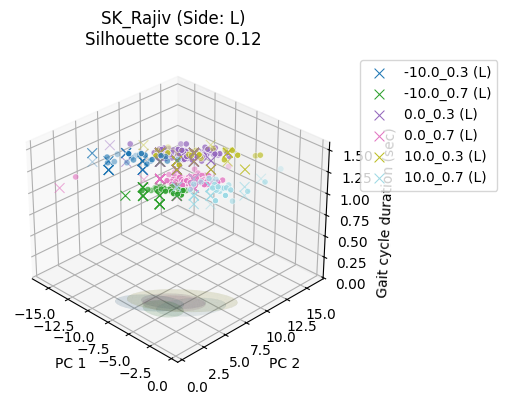

In [121]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# --- USER SETTINGS ---
side = 'L'  # Change to 'L' or 'R' here
# ---------------------

# Categorize pts_L according to label_L
categorized_pts_L = {
    label: pts_L[labels_L == label]
    for label in np.unique(labels_L)
}
categorized_pts_R = {
    label: pts_R[labels_R == label]
    for label in np.unique(labels_R)
}

# 1. Data Selection Logic
if side.upper() == 'R':
    pts = pts_R
    labels = labels_R
    cat_pts = categorized_pts_R
    marker = 'x'  # Diamond for Right
else:
    pts = pts_L
    labels = labels_L
    cat_pts = categorized_pts_L
    marker = 'x'  # Circle for Left

# Re-calculate unique tasks for this side only
unique_tasks = np.unique(labels)
cmap = plt.get_cmap("tab20", len(unique_tasks))
task_to_color = {task: cmap(i) for i, task in enumerate(unique_tasks)}

# 2. Setup Figure and 3D Axis
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')

# 3. Plot Scatter Points for the selected side
n = min(len(pts), len(labels))
pts_final_disc = pts[:n]
labels_final = labels[:n]

for task in unique_tasks:
    mask = labels_final == task
    if not np.any(mask): continue

    ax.scatter(
        pts_final[mask, 0], 
        pts_final[mask, 1], 
        pts_final[mask, 2]/100,
        color=task_to_color[task],
        marker='o',
        s=20,
        edgecolors='white',
        linewidth=0.5,
        label=f"{task} ({side})"
    )

    ax.scatter(
        pts_final_disc[mask, 0]*2, 
        pts_final_disc[mask, 1]*2, 
        pts_final_disc[mask, 2]*10/100,
        color=task_to_color[task],
        marker=marker,
        s=50,
        linewidth=0.75,
        label=f"{task} ({side})"
    )

# 4. Add Ellipsoids for the selected side
for label, pts_cluster in cat_pts.items():
    _add_mpl_ellipsoid(ax, pts_cluster, task_to_color[label])

# 5. Final Formatting
if side == 'L':
    silhouette_score = overall_silhouette_L
else:
    silhouette_score = overall_silhouette_R

ax.set_title(f"{subject} (Side: {side})\nSilhouette score {silhouette_score:.2f}")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("Gait cycle duration (sec)")

# Legend management (only show one entry per task)
handles, plot_labels = ax.get_legend_handles_labels()
by_label = dict(zip(plot_labels, handles))
ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
ax.view_init(elev=30, azim=-45)
plt.tight_layout()
plt.show()

In [ ]:
import pickle
pca_model_file = '/home/metamobility5/Changseob/proj-online_adaptation_GPE/method-replay_buffer/pca_model_pos_1gc_2_50.pkl'
with open(pca_model_file, 'rb') as f:
    pca_data = pickle.load(f)
    
pca_matrix = pca_data['pca_matrix']
print(f"PCA matrix shape loaded: {pca_matrix.shape}")
scaler_mean = pca_data['scaler_mean']
scaler_scale = pca_data['scaler_scale']

In [ ]:
course = 3; inc = 'RD_5'; side = 'R'; ex_cycle = 70

mtr_data = load_jetson_input_mtr_data(f'{root_folder}/{subject}-{condition}-{course}_{inc}-input_motor.csv')
hs_indices_L = detect_heel_strike(mtr_data[:, 5], threshold=0.1, min_interval=90, max_interval=210, side='L')
hs_indices_R = detect_heel_strike(mtr_data[:, 6], threshold=0.1, min_interval=90, max_interval=210, side='R')
print(len(hs_indices_L), len(hs_indices_R))

if side == 'L':
    example_data = mtr_data[hs_indices_L[ex_cycle]:hs_indices_L[ex_cycle+1], 1:3].T  # Take pos_L and pos_R
else:
    example_data = mtr_data[hs_indices_R[ex_cycle]:hs_indices_R[ex_cycle+1], 1:3].T

example_data = upsampling_2d(example_data, target_length=50)  # Upsample to 50 time steps
example_data = example_data.flatten()
# Scale and reduce example data

print(example_data.shape, scaler_mean.shape, scaler_scale.shape)
example_data_scaled = (example_data - scaler_mean) / scaler_scale
example_data_reduced = np.dot(example_data_scaled, pca_matrix)

# Reconstruct example data
example_data_reconstructed_std = np.dot(example_data_reduced, pca_matrix.T)
example_data_reconstructed = example_data_reconstructed_std * scaler_scale + scaler_mean

# Calculate reconstruction error
reconstruction_error = np.sqrt(np.mean((example_data_scaled - example_data_reconstructed_std) ** 2))
print(f"Reconstruction RMSE (Scaled): {reconstruction_error:.3f}")

plot_reconstruction_mtr(example_data, example_data_reconstructed)

# PCA method figure for SK

In [ ]:
condition = 'pc_buffer'
task_list = ['LG_slow', 'LG_fast', 'RA_slow', 'RA_fast', 'RD_slow', 'RD_fast']
task_PC_L = {task: [] for task in task_list}
task_PC_R = {task: [] for task in task_list}

for task in task_list:
    for subject in ['SK_Maria']:
        task_PC_L[task].extend(input_reduced_PC_L[condition][subject][task])
        task_PC_R[task].extend(input_reduced_PC_R[condition][subject][task])
    print(f"Total samples for {task} in PC buffer \t (Left): {len(task_PC_L[task])},\t (Right): {len(task_PC_R[task])}")

from sklearn.metrics import silhouette_score
from scipy.stats import chi2

def parse_points(raw_points):
    parsed = []
    for s in raw_points:
        if isinstance(s, str):
            arr = np.fromstring(s.strip().strip('[]'), sep=' ')
        else:
            arr = np.asarray(s, dtype=float).ravel()
        if arr.size == 3 and np.all(np.isfinite(arr)):
            parsed.append(arr)
    return np.vstack(parsed).astype(float) if parsed else np.empty((0, 3), dtype=float)

def plot_confidence_ellipsoid(ax, points, color, conf=0.99, alpha=0.12, resolution=30):
    if points.shape[0] < 4:
        return

    mean = points.mean(axis=0)
    cov = np.cov(points, rowvar=False)
    cov = cov + 1e-8 * np.eye(3)

    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.clip(eigvals, 1e-8, None)

    scale = np.sqrt(chi2.ppf(conf, df=3))
    radii = scale * np.sqrt(eigvals)

    u = np.linspace(0, 2 * np.pi, resolution)
    v = np.linspace(0, np.pi, resolution)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    sphere = np.stack([x, y, z], axis=0).reshape(3, -1)
    ellipsoid = eigvecs @ np.diag(radii) @ sphere
    ellipsoid = ellipsoid + mean[:, None]

    X = ellipsoid[0].reshape(resolution, resolution)
    Y = ellipsoid[1].reshape(resolution, resolution)
    Z = ellipsoid[2].reshape(resolution, resolution)

    ax.plot_surface(X, Y, Z, color=color, alpha=alpha, linewidth=0, shade=True)

def build_task_arrays(task_pc_dict):
    task_arrays = {task: parse_points(task_pc_dict[task]) for task in task_list}
    nonempty_tasks = [task for task, data in task_arrays.items() if data.shape[0] > 0]

    all_points = (
        np.vstack([task_arrays[task] for task in nonempty_tasks])
        if nonempty_tasks else np.empty((0, 3), dtype=float)
    )
    all_labels = (
        np.concatenate([np.repeat(task, len(task_arrays[task])) for task in nonempty_tasks])
        if nonempty_tasks else np.array([], dtype=str)
    )
    return task_arrays, all_points, all_labels

def plot_side_task_space(ax, task_pc_dict, side_name, colors):
    task_arrays, all_points, all_labels = build_task_arrays(task_pc_dict)
    valid_tasks = [task for task, data in task_arrays.items() if data.shape[0] >= 2]

    if len(valid_tasks) >= 2:
        valid_mask = np.isin(all_labels, valid_tasks)
        sil_score = silhouette_score(all_points[valid_mask], all_labels[valid_mask])
        print(f"Silhouette score ({side_name}) = {sil_score:.4f}")
    else:
        sil_score = np.nan
        print(f"Not enough valid clusters to compute silhouette score for {side_name}.")

    for color, task in zip(colors, task_list):
        data = task_arrays[task]
        if data.shape[0] == 0:
            continue

        ax.scatter(
            data[:, 0], data[:, 1], data[:, 2],
            s=20, alpha=0.7, color=color, label=task
        )
        plot_confidence_ellipsoid(ax, data, color=color, conf=0.90)

    ax.set_title(f'{side_name} silhouette = {sil_score:.2f}')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.set_zlabel('Gait cycle duration (s)')
    ax.legend()
    ax.grid(True)

    return all_points

plt.rcParams['pdf.fonttype'] = 42  # Use TrueType fonts for editable PDF text
colors = plt.cm.tab10(np.linspace(0, 1, len(task_list)))
side_sources = {'Left': task_PC_L, 'Right': task_PC_R}

fig = plt.figure(figsize=(10, 4))
axes = [fig.add_subplot(1, 2, i + 1, projection='3d') for i in range(2)]

side_points = []
for ax, (side_name, task_pc_dict) in zip(axes, side_sources.items()):
    pts = plot_side_task_space(ax, task_pc_dict, side_name, colors)
    if pts.size > 0:
        side_points.append(pts)
    # ax.view_init(elev=30, azim=45)

if side_points:
    combined_points = np.vstack(side_points)
    x_min, x_max = combined_points[:, 0].min(), combined_points[:, 0].max()
    y_min, y_max = combined_points[:, 1].min(), combined_points[:, 1].max()
    z_min, z_max = combined_points[:, 2].min(), combined_points[:, 2].max()

    x_pad = 0.05 * max(x_max - x_min, 1)
    y_pad = 0.05 * max(y_max - y_min, 1)
    z_pad = 0.05 * max(z_max - z_min, 1)

    for ax in axes:
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
        ax.set_zlim(z_min - z_pad, z_max + z_pad)

plt.tight_layout()
plt.savefig('PCA_SK_both_sides.pdf', dpi=300)
plt.show()